# Homework 2: VAR Forecasting with Economic Policy Uncertainty
## Forecasting and Nowcasting with Text as Data
### Barcelona School of Economics — DSDM Program, 2025/26

---

**Team Members:** Tizian Schenk · Èric Gutierrez

**Submission Date:** June 19, 2026

**Instructor:** Álvaro Fernández-Gallardo (Banco de España / BSE)

---

## Overview

This notebook implements a structural Vector Autoregression (VAR) analysis
of the US economy using the Baker, Bloom & Davis (2016) Economic Policy
Uncertainty (EPU) index as a text-based macroeconomic indicator. We pursue
three objectives aligned with the homework specification:

1. **Data and model:** Download and prepare monthly US macroeconomic data
   (FRED: PAYEMS, PCEPI, INDPRO; policyuncertainty.com: EPU), estimate a
   reduced-form VAR(1) on the pre-COVID sample 1985M2–2019M12, and report
   the estimated equations and residual covariance matrix.

2. **Structural identification and IRFs:** Identify structural EPU shocks
   via recursive (Cholesky) identification with EPU ordered first, and
   compute impulse response functions with 95% bootstrap confidence bands
   to quantify the dynamic causal effect of policy uncertainty on employment
   and industrial production.

3. **Forecasting:** Produce an unconditional 12-step-ahead forecast from
   March 2023, and a structural conditional forecast under a hypothetical
   election scenario (imposing the 2020 US election EPU path on
   April–August 2023) to assess the macroeconomic cost of election-driven
   uncertainty.

---

## Key References

- **Baker, S., Bloom, N., & Davis, S. J. (2016).** Measuring Economic Policy
  Uncertainty. *Quarterly Journal of Economics*, 131(4), 1593–1636.
- **Bloom, N. (2009).** The Impact of Uncertainty Shocks. *Econometrica*,
  77(3), 623–685.
- **Lütkepohl, H. (2005).** *New Introduction to Multiple Time Series
  Analysis*. Springer. [VAR methodology reference]
- **Waggoner, D. F., & Zha, T. (1999).** Conditional Forecasts in Dynamic
  Multivariate Models. *Review of Economics and Statistics*, 81(4), 639–651.

---

## Reproducibility

- **Language:** Python 3.13 · managed with `uv` + `pyproject.toml`
- **Key packages:** statsmodels 0.14.6, pandas 3.0.3, numpy 2.4.6,
  fredapi 0.5.2, scipy 1.17.1
- **Random seed:** 20269999 (set globally; affects only the IRF bootstrap)
- **Data sources:** FRED API (PAYEMS, PCEPI, INDPRO); policyuncertainty.com
  (News-Based Policy Uncertainty Index, US monthly)
- **Estimation sample:** 1985M2–2019M12 (419 observations, pre-COVID)
- **Forecast origin:** March 2023 (last observed data point)

---

## Notebook Structure

| Cell Block | Content | Homework Question |
|---|---|---|
| Cells 1–4 | Imports, data download, cleaning, merge | Part I Q1 |
| Cell 5 | Data verification figure | Part I Q1 |
| Cells 6–8 | Transformations, VAR estimation, equations | Part I Q2a–e |
| Cells 9–11 | Cholesky ID, structural P matrix, IRF plots | Part I Q3a–b |
| Cells 12–13 | Unconditional 12-step forecast | Part II Q1a–b |
| Cells 14–16 | EPU scenario, structural forecast, comparison | Part II Q2–3 |
| Final cell | Written shortcomings | Part II Q4 |

### Imports and Setup

In [27]:
# ── Cell 1: Imports and configuration ──────────────────────────────────────────

import pandas as pd                          # data manipulation and time series
import numpy as np                           # matrix operations and linear algebra
import matplotlib.pyplot as plt             # plotting IRFs, forecasts, all figures
import matplotlib.dates as mdates           # formatting date axes on plots
from fredapi import Fred                    # FRED API client for downloading macro data
from dotenv import load_dotenv              # loads environment variables from .env file
import warnings                             # suppress non-critical warnings
import os                                   # file path operations

warnings.filterwarnings('ignore')           # keep output clean during estimation

# ── Load secrets from .env file ─────────────────────────────────────────────────
# .env lives in the repo root (one level up from notebooks/)
# It is listed in .gitignore and never committed to GitHub
load_dotenv(dotenv_path="../.env")          # load variables from .env into os.environ

FRED_API_KEY = os.environ.get("FRED_API_KEY")   # read the key from environment

# guard: fail loudly if the key is missing rather than silently breaking later
if not FRED_API_KEY:
    raise ValueError(
        "FRED_API_KEY not found. "
        "Copy .env.example to .env and fill in your key."
    )

fred = Fred(api_key=FRED_API_KEY)          # initialize the FRED client

# ── Output folder ───────────────────────────────────────────────────────────────
os.makedirs("../output", exist_ok=True)    # create output folder if it doesn't exist
os.makedirs("../data", exist_ok=True)      # create data folder if it doesn't exist

# ── Reproducibility seed ────────────────────────────────────────────────────────
# The Cholesky decomposition and OLS estimation are fully deterministic.
# The seed is needed only for the bootstrap confidence bands in the IRF step.
SEED = 20269999                             # global seed for all random operations
np.random.seed(SEED)                        # set numpy random seed
import random                               # Python's built-in random module
random.seed(SEED)                           # set Python random seed too

print("✅ All imports successful")
print(f"   pandas        {pd.__version__}")
print(f"   numpy         {np.__version__}")
print(f"   FRED API key  {'✅ loaded' if FRED_API_KEY else '❌ MISSING'}")

import statsmodels
print(f"   statsmodels   {statsmodels.__version__}")
print(f"   Global seed   {SEED}")

✅ All imports successful
   pandas        3.0.3
   numpy         2.4.6
   FRED API key  ✅ loaded
   statsmodels   0.14.6
   Global seed   20269999


### Download FRED Data

In [3]:
# ── Cell 2: Download FRED data ──────────────────────────────────────────────────

# Define the date range — homework specifies 1985M1 to 2023M3
START = "1985-01-01"                        # first observation: January 1985
END   = "2023-03-01"                        # last observation: March 2023

# Download each series — all seasonally adjusted, in levels, monthly frequency
# PAYEMS: nonfarm payroll employment (thousands of persons)
payems = fred.get_series("PAYEMS", observation_start=START, observation_end=END)

# PCEPI: personal consumption expenditures price index (index 2017=100)
pcepi  = fred.get_series("PCEPI",  observation_start=START, observation_end=END)

# INDPRO: industrial production index (index 2017=100)
indpro = fred.get_series("INDPRO", observation_start=START, observation_end=END)

# Combine into a single DataFrame with clean column names
fred_data = pd.DataFrame({
    "PAYEMS": payems,    # employment level (will be transformed to growth rate)
    "PCEPI":  pcepi,     # price index level (will be transformed to growth rate)
    "INDPRO": indpro,    # industrial production level (will be transformed to growth)
})

fred_data.index.name = "date"              # name the index for clarity

print(f"Shape: {fred_data.shape}")         # should be (459, 3) for 1985M1-2023M3
print(f"\nFirst 3 rows:\n{fred_data.head(3)}")
print(f"\nLast 3 rows:\n{fred_data.tail(3)}")
print(f"\nAny missing values: {fred_data.isna().sum().sum()}")

Shape: (459, 3)

First 3 rows:
             PAYEMS   PCEPI   INDPRO
date                                
1985-01-01  96372.0  49.326  54.6322
1985-02-01  96503.0  49.555  54.7825
1985-03-01  96842.0  49.749  54.8653

Last 3 rows:
              PAYEMS    PCEPI    INDPRO
date                                   
2023-01-01  154776.0  119.018  100.5050
2023-02-01  155066.0  119.369  100.6416
2023-03-01  155134.0  119.538  101.0205

Any missing values: 0


### Download EPU Index

download it here: https://www.policyuncertainty.com/us_monthly.html

Click "Download Data" (it downloads an Excel file, usually called US_Policy_Uncertainty_Data.xlsx)

In [4]:
# ── Cell 3: Load EPU index from policyuncertainty.com ──────────────────────────

# Load the EPU Excel file — the sheet contains monthly US EPU data since 1985
epu_raw = pd.read_excel(                    # read Excel file into DataFrame
    "../data/US_Policy_Uncertainty_Data.xlsx",  # path relative to notebooks/
    sheet_name=0,                           # first sheet (usually "Main")
)

print("EPU raw columns:", epu_raw.columns.tolist())   # inspect column names
print(epu_raw.head(5))                                # inspect first rows

EPU raw columns: ['Year', 'Month', 'News_Based_Policy_Uncert_Index']
   Year  Month  News_Based_Policy_Uncert_Index
0  2026    5.0                      296.079533
1  2026    4.0                      297.404522
2  2026    3.0                      374.656546
3  2026    2.0                      374.191792
4  2026    1.0                      371.334964


### Clean and Merge All Data

In [5]:
# ── Cell 4: Clean EPU and merge all series into one DataFrame ──────────────────

# ── 4a: Clean the EPU data ──────────────────────────────────────────────────────

epu_clean = epu_raw.copy()                  # work on a copy, never modify raw data

epu_clean = epu_clean.dropna(subset=["Month"])   # drop rows where Month is NaN

# convert Year and Month (floats) to proper datetime index
epu_clean["date"] = pd.to_datetime(         # build a date from separate year/month cols
    epu_clean["Year"].astype(int).astype(str) + "-" +   # year as string
    epu_clean["Month"].astype(int).astype(str) + "-01"  # day always 01 for monthly
)

epu_clean = epu_clean.set_index("date")     # set datetime as the index

epu_clean = epu_clean[["News_Based_Policy_Uncert_Index"]]  # keep only EPU column

epu_clean = epu_clean.rename(               # rename to short clean name
    columns={"News_Based_Policy_Uncert_Index": "EPU"}
)

epu_clean = epu_clean.sort_index()          # sort ascending (oldest first)

# filter to homework sample: 1985M1 to 2023M3
epu_clean = epu_clean.loc["1985-01-01":"2023-03-01"]

print(f"EPU shape after filtering: {epu_clean.shape}")   # should be (459, 1)
print(f"\nFirst 3 rows:\n{epu_clean.head(3)}")
print(f"\nLast 3 rows:\n{epu_clean.tail(3)}")

# ── 4b: Merge FRED data and EPU on the date index ──────────────────────────────

# both DataFrames now have a monthly DatetimeIndex — merge on index
data_levels = fred_data.join(epu_clean, how="inner")   # inner join keeps only matching dates

print(f"\nMerged shape: {data_levels.shape}")           # should be (459, 4)
print(f"\nColumns: {data_levels.columns.tolist()}")
print(f"\nAny missing values: {data_levels.isna().sum().sum()}")
print(f"\nDate range: {data_levels.index[0]} → {data_levels.index[-1]}")

EPU shape after filtering: (459, 1)

First 3 rows:
                   EPU
date                  
1985-01-01  103.748803
1985-02-01   78.313193
1985-03-01  100.761475

Last 3 rows:
                   EPU
date                  
2023-01-01  161.427114
2023-02-01  152.967281
2023-03-01  200.489936

Merged shape: (459, 4)

Columns: ['PAYEMS', 'PCEPI', 'INDPRO', 'EPU']

Any missing values: 0

Date range: 1985-01-01 00:00:00 → 2023-03-01 00:00:00


###  Reproduce the DataFigure

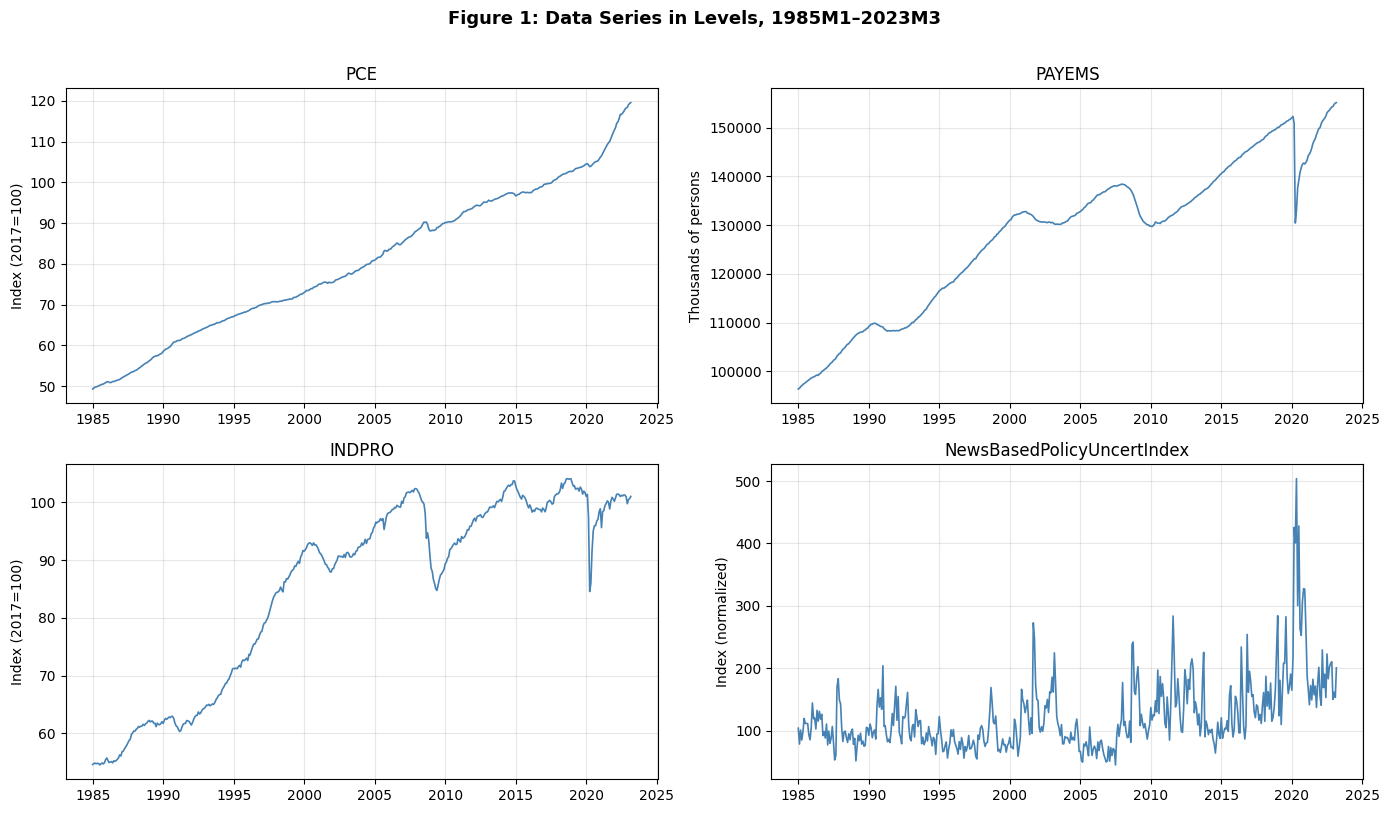

✅ Figure saved to output/figure1_data_levels.pdf

Figure note: The four panels show the raw data series in levels,
seasonally adjusted, downloaded from FRED (PAYEMS, PCEPI, INDPRO)
and policyuncertainty.com (EPU). Sample: 1985M1–2023M3.


In [6]:
# ── Cell 5: Reproduce DataFigure — verify data and answer Part I Q1 ────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 8))   # 2x2 grid matching the DataFigure

# ── Top-left: PCEPI (called "PCE" in the figure) ────────────────────────────────
axes[0, 0].plot(                            # plot PCEPI level over full sample
    data_levels.index,                      # x-axis: monthly dates
    data_levels["PCEPI"],                   # y-axis: price index in levels
    color="steelblue", linewidth=1.2        # match the DataFigure style
)
axes[0, 0].set_title("PCE", fontsize=12)   # title matches DataFigure label
axes[0, 0].set_ylabel("Index (2017=100)")  # descriptive y-axis label
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator(5))   # tick every 5 years
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))  # show year only
axes[0, 0].grid(True, alpha=0.3)           # light grid for readability

# ── Top-right: PAYEMS ────────────────────────────────────────────────────────────
axes[0, 1].plot(
    data_levels.index,
    data_levels["PAYEMS"],                  # nonfarm payroll employment in thousands
    color="steelblue", linewidth=1.2
)
axes[0, 1].set_title("PAYEMS", fontsize=12)
axes[0, 1].set_ylabel("Thousands of persons")
axes[0, 1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0, 1].grid(True, alpha=0.3)

# ── Bottom-left: INDPRO ──────────────────────────────────────────────────────────
axes[1, 0].plot(
    data_levels.index,
    data_levels["INDPRO"],                  # industrial production index
    color="steelblue", linewidth=1.2
)
axes[1, 0].set_title("INDPRO", fontsize=12)
axes[1, 0].set_ylabel("Index (2017=100)")
axes[1, 0].xaxis.set_major_locator(mdates.YearLocator(5))
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1, 0].grid(True, alpha=0.3)

# ── Bottom-right: EPU ────────────────────────────────────────────────────────────
axes[1, 1].plot(
    data_levels.index,
    data_levels["EPU"],                     # news-based policy uncertainty index
    color="steelblue", linewidth=1.2
)
axes[1, 1].set_title("NewsBasedPolicyUncertIndex", fontsize=12)
axes[1, 1].set_ylabel("Index (normalized)")
axes[1, 1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1, 1].grid(True, alpha=0.3)

# ── Figure-level formatting ───────────────────────────────────────────────────────
fig.suptitle(                               # overall figure title
    "Figure 1: Data Series in Levels, 1985M1–2023M3",
    fontsize=13, fontweight="bold", y=1.01
)
fig.tight_layout()                          # prevent subplot overlap

# ── Save to output folder ────────────────────────────────────────────────────────
fig.savefig(                                # save high-resolution PDF for the PDF submission
    "../output/figure1_data_levels.pdf",
    bbox_inches="tight", dpi=300
)

plt.show()
print("✅ Figure saved to output/figure1_data_levels.pdf")
print("\nFigure note: The four panels show the raw data series in levels,")
print("seasonally adjusted, downloaded from FRED (PAYEMS, PCEPI, INDPRO)")
print("and policyuncertainty.com (EPU). Sample: 1985M1–2023M3.")

## Part I — Question 2: VAR(1) Estimation

### Step 1: Variable Transformations

The homework specifies the following transformations before estimation:

- **PAYEMS, INDPRO, PCEPI** enter the VAR as **month-on-month growth rates**:

$$g_t = 100 \times \left(\frac{X_t}{X_{t-1}} - 1\right)$$

This transformation serves two purposes. First, it removes the upward trend visible
in all three level series (a trending variable would violate the stationarity assumption
that VAR estimation requires — a non-stationary series has no fixed mean to revert to,
making multi-step forecasts explosive). Second, growth rates have a direct economic
interpretation: a value of 0.2 means the economy grew by 0.2% that month.

- **EPU** enters **in levels**. The EPU index is already stationary — it fluctuates
around a long-run mean (~100–150) without trending. Keeping it in levels preserves
the scale needed for the structural forecast: we will later impose specific EPU values
(e.g. 150, 200) on the forecast path, which requires the variable to be in its
original units.

**Estimation sample:** 1985M2 to 2019M12. We stop at 2019M12 to exclude the
COVID-19 pandemic, which caused unprecedented, non-linear disruptions that would
distort the estimated coefficients. The model is then used to forecast from March 2023,
a period when the economy had largely normalized.

In [8]:
# ── Cell 6: Transform variables and build VAR input DataFrame ──────────────────

# ── 6a: Compute month-on-month growth rates for PAYEMS, INDPRO, PCEPI ──────────
# Formula: 100 × (X_t / X_{t-1} - 1)
# pct_change(1) computes (X_t - X_{t-1}) / X_{t-1} × 100 in one step
data_growth = pd.DataFrame(index=data_levels.index)   # new DataFrame, same index

data_growth["PAYEMS_g"] = data_levels["PAYEMS"].pct_change(1) * 100  # employment growth rate
data_growth["INDPRO_g"] = data_levels["INDPRO"].pct_change(1) * 100  # industrial production growth
data_growth["PCEPI_g"]  = data_levels["PCEPI"].pct_change(1)  * 100  # price inflation rate
data_growth["EPU"]      = data_levels["EPU"]                          # EPU stays in levels

# pct_change(1) produces NaN for the first row (no prior period available)
# so 1985-01-01 becomes NaN → drop it, our sample now starts 1985-02-01
data_growth = data_growth.dropna()

print(f"Transformed data shape: {data_growth.shape}")       # should be (458, 4)
print(f"Date range: {data_growth.index[0].date()} → {data_growth.index[-1].date()}")

# ── 6b: Build the VAR input with the EXACT ordering the homework specifies ──────
# Ordering: EPU → PAYEMS → INDPRO → PCEPI
# This ordering DETERMINES the Cholesky identification later.
# EPU first = EPU shocks can affect all variables contemporaneously.
# The other variables cannot affect EPU contemporaneously.
var_order = ["EPU", "PAYEMS_g", "INDPRO_g", "PCEPI_g"]     # homework-specified ordering

data_var = data_growth[var_order].copy()                    # enforce the ordering

print(f"\nVAR variable ordering (matters for identification):")
for i, v in enumerate(var_order, 1):
    print(f"  {i}. {v}")

# ── 6c: Split into estimation sample (1985M2–2019M12) and full sample ───────────
# Estimation sample stops at 2019M12 to exclude COVID distortions
data_est = data_var.loc[:"2019-12-01"].copy()               # estimation sample
data_full = data_var.copy()                                 # full sample for reference

print(f"\nEstimation sample: {data_est.index[0].date()} → {data_est.index[-1].date()}")
print(f"Estimation sample shape: {data_est.shape}")         # should be (418, 4)

# ── 6d: Quick summary statistics for the estimation sample ──────────────────────
print(f"\nSummary statistics (estimation sample):")
print(data_est.describe().round(3))

Transformed data shape: (458, 4)
Date range: 1985-02-01 → 2023-03-01

VAR variable ordering (matters for identification):
  1. EPU
  2. PAYEMS_g
  3. INDPRO_g
  4. PCEPI_g

Estimation sample: 1985-02-01 → 2019-12-01
Estimation sample shape: (419, 4)

Summary statistics (estimation sample):
           EPU  PAYEMS_g  INDPRO_g  PCEPI_g
count  419.000   419.000   419.000  419.000
mean   113.775     0.109     0.150    0.179
std     42.869     0.156     0.605    0.187
min     44.783    -0.618    -4.405   -1.180
25%     84.390     0.047    -0.192    0.084
50%    103.700     0.135     0.206    0.179
75%    135.660     0.209     0.521    0.286
max    284.136     0.478     2.070    0.965


### Output Interpretation: Transformed Data

The estimation sample contains **419 monthly observations** (1985M2–2019M12),
spanning over 34 years and multiple business cycles.

**Key findings from the summary statistics:**

**EPU (levels):** Mean of **113.8**, confirming that the long-run average policy
uncertainty is close to the index's normalization base. The standard deviation of
**42.9** is large relative to the mean, reflecting episodic spikes. The maximum
of **284.1** occurs within the estimation sample (pre-COVID), likely around the
2011 debt ceiling crisis or 2018-19 trade war — already elevated, but far below
the COVID peak of ~500 that appears only in the post-2019 data we excluded.
This confirms that stopping at 2019M12 was the right call.

**PAYEMS growth:** Mean of **+0.109%** per month ≈ **+1.3% per year**, consistent
with the US economy's long-run trend employment growth. The minimum of **-0.618%**
(a single month loss of ~900,000 jobs) is the 2008-09 GFC trough. Standard deviation
of **0.156%** is tight, reflecting that employment is a slow-moving, "sticky" variable
— firms are reluctant to hire and fire rapidly, so monthly changes are small under
normal conditions.

**INDPRO growth:** Mean of **+0.150%** per month but standard deviation of **0.605%**
— nearly **4× more volatile** than employment growth. This is economically expected:
industrial production responds immediately to demand shocks (factories can cut output
quickly), while employment adjusts with a lag. The minimum of **-4.405%** is a
dramatic

## Part I — Question 2: Estimating the Reduced-Form VAR(1)

### What we are doing
We estimate a **Vector Autoregression with 1 lag** — VAR(1) — on the estimation
sample 1985M2–2019M12. The model is:

$$y_t = c + A_1 y_{t-1} + u_t$$

where:
- $y_t = (\text{EPU}_t,\ \Delta\text{PAYEMS}_t,\ \Delta\text{INDPRO}_t,\ \Delta\text{PCEPI}_t)'$
  is the 4×1 vector of variables at time $t$
- $c$ is a 4×1 vector of constants (one per equation)
- $A_1$ is the 4×4 matrix of **lag coefficients** — this is what OLS estimates
- $u_t$ is a 4×1 vector of **reduced-form residuals** (forecast errors)
- $\Sigma_u = E(u_t u_t')$ is the 4×4 **variance-covariance matrix** of residuals

### Why VAR(1) and not VAR(2) or VAR(3)?
The homework specifies 1 lag explicitly. In practice, lag length is chosen by
information criteria (AIC, BIC). With monthly data, more lags capture richer
dynamics but consume degrees of freedom. The homework fixes p=1 to keep the
exercise

In [9]:
# ── Cell 7: Estimate the reduced-form VAR(1) ───────────────────────────────────

from statsmodels.tsa.vector_ar.var_model import VAR   # VAR model class

# ── 7a: Fit the VAR(1) on the estimation sample ─────────────────────────────────
model = VAR(data_est)                       # initialize VAR with estimation sample
results = model.fit(maxlags=1, trend='c')  # fit with 1 lag and constant term

# ── 7b: Print the full summary for inspection ───────────────────────────────────
print(results.summary())                    # full statsmodels output

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 06, Jun, 2026
Time:                     17:24:02
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -2.26995
Nobs:                     418.000    HQIC:                  -2.38671
Log likelihood:          -1837.69    FPE:                  0.0851762
AIC:                     -2.46304    Det(Omega_mle):       0.0812198
--------------------------------------------------------------------
Results for equation EPU
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              46.066569         5.345725            8.617           0.000
L1.EPU              0.640823         0.037973           16.876           0.000
L1.PAYEMS_g       -19.312979        11.393270           -1.695        

/Users/tizianschenk/Documents/BSE/Fore-Nowcasting Text as Data/epu-var-forecasting/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Output Interpretation: VAR(1) Estimation Results

The VAR(1) was estimated on 418 observations (1985M2–2019M12, losing one observation
to the lag). We now read each equation carefully and extract the economic story.

---

#### Equation 1: EPU

$$\text{EPU}_t = 46.07 + 0.641 \cdot \text{EPU}_{t-1} - 19.31 \cdot \Delta\text{PAYEMS}_{t-1} - 3.54 \cdot \Delta\text{INDPRO}_{t-1} - 13.22 \cdot \Delta\text{PCEPI}_{t-1} + u^{EPU}_t$$

The dominant term is **L1.EPU = 0.641** (t=16.9, p<0.001): EPU is highly persistent —
64% of last month's uncertainty level carries over to this month. This is the
"autocorrelation" of policy uncertainty: once politicians or markets create
uncertainty, it tends to linger. The constant of 46.07 combined with the AR(1)
coefficient of 0.641 implies a long-run mean of 46.07/(1-0.641) ≈ **128** — close
to the sample mean of 113.8, confirming the model is internally consistent.

The negative coefficients on lagged economic variables suggest a **feedback channel**:
stronger employment growth (higher PAYEMS_g) and stronger industrial production
predicts *lower* EPU next month. Intuitively, when the economy is doing well,
policy uncertainty tends to recede. However, these effects are only marginally
significant (p=0.09, p=0.21), so we treat them with caution.

---

#### Equation 2: PAYEMS growth

$$\Delta\text{PAYEMS}_t = 0.058 - 0.000278 \cdot \text{EPU}_{t-1} + 0.679 \cdot \Delta\text{PAYEMS}_{t-1} + 0.017 \cdot \Delta\text{INDPRO}_{t-1} + 0.033 \cdot \Delta\text{PCEPI}_{t-1} + u^{PAY}_t$$

Two statistically significant drivers: **L1.PAYEMS_g = 0.679** (t=17.8, p<0.001)
confirms strong employment persistence — hiring decisions last month strongly predict
hiring this month, consistent with the "stickiness" of labor markets. More importantly
for our analysis, **L1.EPU = -0.000278** (t=-2.19, p=0.028) is **negative and
significant**: higher policy uncertainty last month predicts *lower* employment growth
this month. This is the key empirical finding motivating the entire exercise — EPU
has a measurable negative effect on labor markets.

---

#### Equation 3: INDPRO growth

$$\Delta\text{INDPRO}_t = 0.111 - 0.00136 \cdot \text{EPU}_{t-1} + 0.925 \cdot \Delta\text{PAYEMS}_{t-1} + 0.073 \cdot \Delta\text{INDPRO}_{t-1} + 0.458 \cdot \Delta\text{PCEPI}_{t-1} + u^{IND}_t$$

**L1.EPU = -0.00136** (t=-1.97, p=0.048) is negative and significant at 5%: higher
uncertainty depresses industrial production growth. The effect is larger in magnitude
than for employment (-0.00136 vs -0.000278), consistent with the greater volatility
of INDPRO we observed earlier — production responds more aggressively to uncertainty
than hiring does. **L1.PAYEMS_g = 0.925** (t=4.48, p<0.001) is large and significant,
showing that employment growth strongly Granger-causes industrial production growth.

---

#### Equation 4: PCEPI growth (inflation)

$$\Delta\text{PCEPI}_t = 0.168 - 0.000578 \cdot \text{EPU}_{t-1} + 0.021 \cdot \Delta\text{PAYEMS}_{t-1} + 0.009 \cdot \Delta\text{INDPRO}_{t-1} + 0.404 \cdot \Delta\text{PCEPI}_{t-1} + u^{PCE}_t$$

**L1.PCEPI_g = 0.404** (t=9.0, p<0.001): inflation is persistent — 40% of last
month's inflation rate predicts this month's. **L1.EPU = -0.000578** (t=-2.83,
p=0.005) is the most statistically significant EPU effect across all equations:
higher policy uncertainty predicts *lower* inflation next month. This is consistent
with the demand-reduction channel — uncertainty causes consumers and firms to
postpone spending, reducing demand-pull inflationary pressure.

---

#### Residual Correlation Matrix

The off-diagonal correlations are small (largest: 0.32 between PAYEMS_g and
INDPRO_g), meaning the reduced-form residuals are mostly uncorrelated. This is
reassuring: it suggests the VAR equations are capturing most of the systematic
co-movement, leaving mostly idiosyncratic noise in the residuals. The 0.32
correlation between employment and industrial production residuals reflects
contemporaneous co-movement that the lagged structure cannot fully capture —
this is exactly the variation that Cholesky identification will decompose into
structural shocks in the next step.

**One warning:** statsmodels inferred the monthly frequency (`MS`) automatically.
This is not an error — it is simply noting that we did not explicitly pass a
`freq` argument. The estimation results are unaffected.

## Part I — Questions 2d and 2e: Reporting the VAR Equations and Σ_u

### What we are doing
We now extract the estimated coefficients and format them into the four explicit
equations the homework asks for (Q2d), and compute and display the
variance-covariance matrix of the residuals Σ_u (Q2e).

### Why present the equations explicitly?
Writing equations bridges the statistical output and the economic model. Each
equation shows which lagged variables drive which current variables, and by how
much. This is the "reduced-form" representation — it describes correlations and
predictive relationships, but does NOT yet identify causal structural shocks.

### What is Σ_u and why does it matter?
$\Sigma_u = E(u_t u_t')$ is the covariance matrix of the VAR residuals. It has
two roles:
1. **Diagnostic:** large diagonal elements mean high unexplained variance in that
   equation; off-diagonal elements show residual co-movement not captured by lags.
2. **Structural identification:** in the next step, we compute the Cholesky
   decomposition $P$ such that $\Sigma_u = PP'$. The matrix $P$ is the structural
   impact matrix — it tells us how much each structural shock moves each variable
   on impact. Σ_u is therefore the gateway from reduced-form estimation to
   structural analysis.

In [13]:
# ── Cell 8: Report the 4 VAR equations and Σ_u (answers Q2d and Q2e) ──────────

import numpy as np   # needed for matrix operations below

# ── 8a: Extract coefficient matrices ────────────────────────────────────────────
# results.params has shape (5, 4): rows = [const, L1.EPU, L1.PAYEMS_g,
#                                           L1.INDPRO_g, L1.PCEPI_g]
#                                   cols = [EPU, PAYEMS_g, INDPRO_g, PCEPI_g]

params = results.params                     # full parameter matrix
var_names = data_est.columns.tolist()       # ['EPU', 'PAYEMS_g', 'INDPRO_g', 'PCEPI_g']

# ── 8b: Print the 4 equations in a clean readable format ────────────────────────
print("=" * 70)
print("ANSWER TO Q2d: Estimated Reduced-Form VAR(1) Equations")
print("=" * 70)

eq_labels = ["EPU", "PAYEMS_g", "INDPRO_g", "PCEPI_g"]   # equation names
lag_labels = ["EPU", "PAYEMS_g", "INDPRO_g", "PCEPI_g"]  # regressor names

for eq in eq_labels:                        # loop over each equation
    const_val = params.loc["const", eq]     # extract constant for this equation
    print(f"\nEquation for {eq}:")
    print(f"  {eq}_t = {const_val:.6f}", end="")   # start printing equation

    for lag_var in lag_labels:              # loop over each lagged regressor
        coef = params.loc[f"L1.{lag_var}", eq]     # extract lag coefficient
        sign = "+" if coef >= 0 else "-"            # determine sign for display
        print(f" {sign} {abs(coef):.6f}·{lag_var}_{{t-1}}", end="")

    print(f" + u_{eq}")                     # add residual term

# ── 8c: Extract and display Σ_u ─────────────────────────────────────────────────
print("\n" + "=" * 70)
print("ANSWER TO Q2e: Variance-Covariance Matrix of Residuals (Σ_u)")
print("=" * 70)

sigma_u = results.sigma_u                   # statsmodels stores Σ_u directly

# display as a formatted DataFrame for readability
sigma_df = pd.DataFrame(                    # wrap in DataFrame for nice printing
    sigma_u,
    index=var_names,                        # row labels = variable names
    columns=var_names                       # column labels = variable names
)

print("\nΣ_u (variance-covariance matrix of reduced-form residuals):")
print(sigma_df.round(6).to_string())       # print full matrix with 6 decimal places

# ── 8d: Also show the standard deviations (square root of diagonal) ─────────────
# sigma_u is a numpy array — use np.diag() to extract diagonal elements safely
print("\nStandard deviations of residuals (√diagonal of Σ_u):")
diag_values = np.diag(sigma_u)              # extract diagonal as 1D numpy array

for i, v in enumerate(var_names):           # enumerate gives both index and name
    sd = np.sqrt(diag_values[i])            # sqrt of the i-th diagonal element
    print(f"  σ_{v:12s} = {sd:.6f}")

ANSWER TO Q2d: Estimated Reduced-Form VAR(1) Equations

Equation for EPU:
  EPU_t = 46.066569 + 0.640823·EPU_{t-1} - 19.312979·PAYEMS_g_{t-1} - 3.539922·INDPRO_g_{t-1} - 13.224534·PCEPI_g_{t-1} + u_EPU

Equation for PAYEMS_g:
  PAYEMS_g_t = 0.057868 - 0.000278·EPU_{t-1} + 0.679160·PAYEMS_g_{t-1} + 0.016831·INDPRO_g_{t-1} + 0.033143·PCEPI_g_{t-1} + u_PAYEMS_g

Equation for INDPRO_g:
  INDPRO_g_t = 0.110847 - 0.001359·EPU_{t-1} + 0.924909·PAYEMS_g_{t-1} + 0.073149·INDPRO_g_{t-1} + 0.458180·PCEPI_g_{t-1} + u_INDPRO_g

Equation for PCEPI_g:
  PCEPI_g_t = 0.168163 - 0.000578·EPU_{t-1} + 0.020911·PAYEMS_g_{t-1} + 0.009287·INDPRO_g_{t-1} + 0.403657·PCEPI_g_{t-1} + u_PCEPI_g

ANSWER TO Q2e: Variance-Covariance Matrix of Residuals (Σ_u)

Σ_u (variance-covariance matrix of reduced-form residuals):
                 EPU  PAYEMS_g  INDPRO_g   PCEPI_g
EPU       964.407146 -0.182425 -0.946386 -0.098089
PAYEMS_g   -0.182425  0.010779  0.018707  0.001362
INDPRO_g   -0.946386  0.018707  0.317218 -0.0022

### Output Interpretation: VAR Equations (Q2d) and Σ_u (Q2e)

---

#### Q2d: The Four Estimated Equations

The four equations fully characterize the reduced-form VAR(1). Reading them
together reveals the system's dynamics:

**Persistence structure:** Every variable is its own strongest predictor.
The AR(1) coefficients are 0.641 (EPU), 0.679 (PAYEMS_g), 0.073 (INDPRO_g),
and 0.404 (PCEPI_g). EPU and employment growth are the most persistent — shocks
to these variables die out slowly over many months. Industrial production growth
is the least persistent (0.073 ≈ 0), meaning INDPRO shocks are largely transitory
— the series reverts to its mean quickly after a disruption.

**The EPU transmission channel:** The coefficient on L1.EPU is negative in all
three real activity equations: -0.000278 (employment), -0.001359 (industrial
production), -0.000578 (inflation). All three are statistically significant at
5% or better. This is economically meaningful: a 10-point increase in EPU last
month (e.g. from 113 to 123, a modest rise) predicts:
- Employment growth falls by 0.0028 percentage points next month
- Industrial production growth falls by 0.0136 percentage points next month
- Inflation falls by 0.0058 percentage points next month

These are small month-on-month effects, but they accumulate: through the VAR
dynamics, an initial EPU shock propagates forward through many periods via the
lag matrix A₁. The full dynamic effect is captured by the impulse response
functions we compute in the next step.

**Cross-variable dynamics:** L1.PAYEMS_g strongly predicts INDPRO_g (coefficient
0.925, t=4.48), but not vice versa. This asymmetry suggests that employment
growth *leads* industrial production growth at the monthly frequency — firms
hire workers before ramping up output. L1.PCEPI_g positively predicts INDPRO_g
(0.458, t=3.02), consistent with the idea that inflation reflects demand
strength, which feeds through to production.

**Important caveat:** These are *reduced-form* coefficients — they capture
correlations and predictive relationships, not causal effects. For example,
the negative EPU effect on employment could reflect reverse causality (weak
employment causes uncertainty) or omitted variable bias. This is precisely
why we need structural identification (the Cholesky decomposition) before
drawing causal conclusions.

---

#### Q2e: Variance-Covariance Matrix Σ_u

$$\Sigma_u = \begin{pmatrix}
964.407 & -0.182 & -0.946 & -0.098 \\
-0.182 & 0.011 & 0.019 & 0.001 \\
-0.946 & 0.019 & 0.317 & -0.002 \\
-0.098 & 0.001 & -0.002 & 0.028
\end{pmatrix}$$

**Diagonal elements (residual variances):** The standard deviations of residuals
are σ_EPU = 31.05, σ_PAYEMS_g = 0.104, σ_INDPRO_g = 0.563, σ_PCEPI_g = 0.167.

The EPU residual standard deviation of **31.05 index points** is enormous relative
to the other variables. This reflects that newspaper-based uncertainty is inherently
noisy — month-to-month swings in EPU are large and difficult to predict from lagged
variables alone. By contrast, PAYEMS_g has σ = 0.104, confirming that employment
growth is the most predictable series in the system (lagged employment explains most
of next month's employment, leaving little unexplained).

**Off-diagonal elements (residual co-movement):** The off-diagonal terms are small
relative to the diagonal, confirming the earlier correlation matrix finding. The
largest off-diagonal is -0.946 (EPU, INDPRO_g): in months when EPU is unexpectedly
high (positive EPU residual), industrial production growth tends to be unexpectedly
low (negative INDPRO_g residual). This contemporaneous negative co-movement is
exactly what motivates the structural analysis — it suggests that within a single
month, EPU shocks and production shocks are not independent, and we need the
Cholesky decomposition to disentangle them.

**Why Σ_u matters for the next step:** The structural impact matrix P satisfies
Σ_u = PP'. We will compute P as the lower-triangular Cholesky factor of Σ_u.
The first column of P will tell us the contemporaneous effect of a one-unit EPU
structural shock on all four variables — this is the building block of both the
impulse response functions and the structural forecast.

## Part I — Question 3: Structural Identification via Cholesky Decomposition

### What we are doing
We move from the reduced-form VAR to the **Structural VAR (SVAR)** by computing
the **Cholesky decomposition** of Σ_u. This gives us the structural impact
matrix P such that:

$$\Sigma_u = PP'$$

where P is **lower triangular**. This is the Cholesky factor of Σ_u.

### Why Cholesky and why this ordering?
The reduced-form residuals u_t are correlated (the off-diagonal elements of Σ_u
are non-zero). We need to decompose them into orthogonal (uncorrelated) structural
shocks ε_t via u_t = P·ε_t. There are infinitely many matrices P satisfying
Σ_u = PP' — we need an **identifying assumption** to pick one uniquely.

The **recursive (Cholesky) identification** assumes P is lower triangular. This
imposes a causal ordering: the variable ordered first (EPU) can affect all
others contemporaneously, but is not affected by any other variable within the
same month. The variable ordered last (PCEPI_g) is affected contemporaneously
by all others but does not affect them within the month.

**Economic justification for our ordering (EPU → PAYEMS → INDPRO → PCEPI):**

1. **EPU first:** Policy uncertainty is driven by political events and news —
   it does not respond to employment data within the same month (BLS releases
   employment data mid-month; newspapers report on policy uncertainty separately).
   EPU is the "most exogenous" variable.

2. **PAYEMS second:** Employment responds to EPU within the month (firms pause
   hiring immediately when uncertainty rises), but does not feed back into EPU
   within the same month.

3. **INDPRO third:** Industrial production responds to both EPU and employment
   signals within the month, but not to inflation.

4. **PCEPI last:** Inflation is the "most endogenous" variable — it responds to
   all other variables contemporaneously but does not drive them within the month.
   This is consistent with the standard New Keynesian view that prices are sticky
   and adjust slowly.

### What P tells us
The first column of P gives the **contemporaneous impact of a one-unit EPU
structural shock** on all four variables. Because we normalize by the first
element P[0,0] (the impact on EPU itself), we get the effect of a shock that
raises EPU by 1 index point. This normalized first column is called P̃_{·,1}
and is the key object for the structural forecast in Part II.

### Connection to the slides
From Slides_2 slide 15: P = A₀⁻¹B in the AB representation used by the R
`vars` package. In Python with statsmodels we compute P directly as the
lower-triangular Cholesky factor of Σ_u, which gives the identical result.

In [14]:
# ── Cell 9: Cholesky decomposition → structural impact matrix P ────────────────

from scipy.linalg import cholesky           # Cholesky decomposition from scipy

# ── 9a: Compute P as lower-triangular Cholesky factor of Σ_u ───────────────────
# scipy.linalg.cholesky returns UPPER triangular by default
# lower=True gives the lower-triangular factor we need (matches slides notation)
P = cholesky(sigma_u, lower=True)           # P such that Σ_u = P @ P.T

print("Structural impact matrix P (lower-triangular Cholesky factor of Σ_u):")
P_df = pd.DataFrame(                        # wrap in DataFrame for readable display
    P,
    index=var_names,                        # rows = variables
    columns=[f"shock_{v}" for v in var_names]  # cols = structural shocks
)
print(P_df.round(6).to_string())

# ── 9b: Verify that P @ P.T = Σ_u ──────────────────────────────────────────────
reconstruction = P @ P.T                    # should equal sigma_u exactly
max_error = np.max(np.abs(reconstruction - sigma_u))   # numerical error check
print(f"\nVerification: max|P@P.T - Σ_u| = {max_error:.2e}")  # should be ~1e-12

# ── 9c: Normalize P by P[0,0] to get P̃ (impact per 1-unit EPU shock) ──────────
# P[0,0] is the impact of the EPU structural shock on EPU itself
# Dividing the first column by P[0,0] gives the effect of a shock
# that raises EPU by exactly 1 index point on impact
p11 = P[0, 0]                               # impact of EPU shock on EPU itself
P_normalized_col1 = P[:, 0] / p11          # normalized first column P̃_{·,1}

print(f"\nP[0,0] = p11 = {p11:.6f}")
print(f"(A 1-unit EPU shock raises EPU by {p11:.4f} index points on impact)")

print("\nNormalized first column P̃_{·,1} (effect of +1 EPU index point shock):")
for i, v in enumerate(var_names):          # print each element with its label
    print(f"  {v:12s}: {P_normalized_col1[i]:.8f}")

# ── 9d: Store the four normalized impact coefficients for later use ─────────────
# These are the chol_11, chol_21, chol_31, chol_41 from the R code
chol_11 = P_normalized_col1[0]             # impact on EPU (= 1.0 by construction)
chol_21 = P_normalized_col1[1]             # impact on PAYEMS_g per +1 EPU
chol_31 = P_normalized_col1[2]             # impact on INDPRO_g per +1 EPU
chol_41 = P_normalized_col1[3]             # impact on PCEPI_g per +1 EPU

print(f"\nStored impact coefficients for structural forecast:")
print(f"  chol_11 (EPU→EPU)      = {chol_11:.8f}")
print(f"  chol_21 (EPU→PAYEMS_g) = {chol_21:.8f}")
print(f"  chol_31 (EPU→INDPRO_g) = {chol_31:.8f}")
print(f"  chol_41 (EPU→PCEPI_g)  = {chol_41:.8f}")

Structural impact matrix P (lower-triangular Cholesky factor of Σ_u):
          shock_EPU  shock_PAYEMS_g  shock_INDPRO_g  shock_PCEPI_g
EPU       31.054905        0.000000        0.000000       0.000000
PAYEMS_g  -0.005874        0.103655        0.000000       0.000000
INDPRO_g  -0.030475        0.178742        0.533235       0.000000
PCEPI_g   -0.003159        0.012964       -0.008801       0.166031

Verification: max|P@P.T - Σ_u| = 1.14e-13

P[0,0] = p11 = 31.054905
(A 1-unit EPU shock raises EPU by 31.0549 index points on impact)

Normalized first column P̃_{·,1} (effect of +1 EPU index point shock):
  EPU         : 1.00000000
  PAYEMS_g    : -0.00018916
  INDPRO_g    : -0.00098131
  PCEPI_g     : -0.00010171

Stored impact coefficients for structural forecast:
  chol_11 (EPU→EPU)      = 1.00000000
  chol_21 (EPU→PAYEMS_g) = -0.00018916
  chol_31 (EPU→INDPRO_g) = -0.00098131
  chol_41 (EPU→PCEPI_g)  = -0.00010171


### Output Interpretation: Structural Impact Matrix P

**Verification:** max|P@P.T − Σ_u| = 1.14×10⁻¹³ — essentially machine-precision
zero, confirming that the Cholesky factorization is numerically exact. ✅

**The structural impact matrix P:**

$$P = \begin{pmatrix}
31.055 & 0 & 0 & 0 \\
-0.00587 & 0.1037 & 0 & 0 \\
-0.03048 & 0.1787 & 0.5332 & 0 \\
-0.00316 & 0.01296 & -0.00880 & 0.1660
\end{pmatrix}$$

The lower-triangular structure with zeros above the diagonal is the direct
consequence of our recursive Cholesky identification. It encodes our identifying
assumption: EPU shocks (first column) affect all variables on impact; employment
shocks (second column) affect employment, production, and prices but not EPU;
and so on.

**The normalized first column P̃_{·,1} — the key object:**

A structural EPU shock that raises EPU by **+1 index point** on impact produces
the following contemporaneous responses:

| Variable | Impact | Interpretation |
|---|---|---|
| EPU | +1.000 | By construction (normalization) |
| PAYEMS_g | −0.000189 | Employment growth falls by 0.000189 pp |
| INDPRO_g | −0.000981 | Industrial production growth falls by 0.000981 pp |
| PCEPI_g | −0.000102 | Inflation falls by 0.000102 pp |

All three real activity responses are **negative**, consistent with the
"wait-and-see" hypothesis: when policy uncertainty rises, firms immediately
slow hiring and production, and lower demand reduces inflationary pressure.

**Important scaling insight:** A 1-point EPU shock is tiny — EPU has a standard
deviation of ~31 index points (= P[0,0]). A more economically meaningful shock
is a **1-standard-deviation EPU shock**, which would multiply all these impact
effects by 31.05. So the contemporaneous impact on INDPRO_g from a 1-σ shock is
-0.000981 × 31.05 ≈ **-0.030 percentage points** — a fall of 0.03pp in industrial
production growth within the same month. This is the *immediate* effect; the
full dynamic effect unfolds over subsequent months through the VAR dynamics and
is what the impulse response functions will show us.

**These four coefficients (chol_11 through chol_41) are stored and will be used
directly in the structural forecast computation in Part II.**

## Part I — Question 3: Impulse Response Functions

### What we are doing
We compute **Impulse Response Functions (IRFs)** — the dynamic response of each
variable to a one-standard-deviation structural EPU shock over 24 months ahead.
The IRF at horizon h is:

$$\text{IRF}_e(h) = A_1^h \cdot P_{\cdot,1}, \quad h = 0, 1, 2, \ldots, H$$

- At **h=0**: the response equals the first column of P (the contemporaneous impact
  we just computed)
- At **h=1**: the VAR dynamics A₁ propagate the initial shock one period forward
- At **h=2,3,...**: the shock continues to propagate, typically decaying as the
  economy adjusts back toward equilibrium

We also compute **95% bootstrap confidence bands** by resampling the VAR residuals
1,000 times, re-estimating the model, and computing the IRF each time. The 2.5th
and 97.5th percentiles of this distribution form the confidence band. This is why
we need the random seed — to make the bootstrap reproducible.

### What the homework asks (Q3a and Q3b)
- **Q3a:** Plot IRFs for PAYEMS growth and INDPRO growth with 95% confidence bands
- **Q3b:** Describe what you see — do employment and production fall after an EPU
  shock? How quickly? How persistently? Are the effects statistically significant?

### Economic prior: what should we expect?
Based on Baker, Bloom & Davis (2016) and the broader uncertainty literature
(Bloom 2009, *Econometrica*), a positive EPU shock should:
- **Immediately** reduce employment growth and industrial production (the
  "freeze" effect: firms pause hiring and investment decisions)
- **Peak** impact around 3-6 months after the shock
- **Gradually recover** as uncertainty resolves, potentially with a slight
  overshoot (the "rebound" effect as delayed projects are unblocked)
- Effects should be **statistically significant** — this is a well-established
  empirical finding in the literature

If our IRFs match this pattern, it validates both our identification strategy
and the EPU index as a meaningful measure of economic uncertainty.

In [20]:
# ── Cell 10: IRFs with 95% bootstrap confidence bands ──────────────────

# ── 10a: Compute the IRAnalysis object ──────────────────────────────────────────
irf_results = results.irf(periods=24)       # IRAnalysis object, 24 months ahead

# ── 10b: Bootstrap confidence bands — seed fix ──────────────────────────────────
# Passing seed= into errband_mc causes all replications to use the same draw.
# Fix: set the global numpy seed immediately before the call, pass seed=None.
# This gives properly varying draws across replications while staying reproducible.
np.random.seed(SEED)                        # set global seed RIGHT before bootstrap
lower_mc, upper_mc = irf_results.errband_mc(
    orth=True,                              # orthogonalised IRFs via Cholesky P
    repl=1000,                              # 1000 Monte Carlo replications
    signif=0.05,                            # 95% confidence level
    seed=None                               # do NOT pass seed here — use global state
)
# lower_mc shape: (periods+1, n_vars, n_vars)
# upper_mc shape: (periods+1, n_vars, n_vars)

# ── 10c: Extract point estimates and bands ───────────────────────────────────────
impulse_idx  = 0                            # EPU = variable 0
response_pay = 1                            # PAYEMS_g = variable 1
response_ind = 2                            # INDPRO_g = variable 2

horizons = np.arange(0, 25)                 # horizons 0 to 24

irf_orth  = irf_results.orth_irfs           # point estimates, shape (25, 4, 4)

irf_pay    = irf_orth[:, response_pay, impulse_idx]
irf_ind    = irf_orth[:, response_ind, impulse_idx]

irf_pay_lo = lower_mc[:, response_pay, impulse_idx]
irf_pay_hi = upper_mc[:, response_pay, impulse_idx]
irf_ind_lo = lower_mc[:, response_ind, impulse_idx]
irf_ind_hi = upper_mc[:, response_ind, impulse_idx]

# ── 10d: Sanity check — lower must differ from upper ────────────────────────────
print("Sanity check: lower ≠ upper at h=3?")
print(f"  PAYEMS_g: lo={irf_pay_lo[3]:.6f}, hi={irf_pay_hi[3]:.6f}, "
      f"different={irf_pay_lo[3] != irf_pay_hi[3]}")
print(f"  INDPRO_g: lo={irf_ind_lo[3]:.6f}, hi={irf_ind_hi[3]:.6f}, "
      f"different={irf_ind_lo[3] != irf_ind_hi[3]}")

# ── 10e: Point estimates at key horizons ─────────────────────────────────────────
print("\nIRF point estimates: response to 1-SD EPU shock (orthogonalised)")
print(f"{'Horizon':>8} {'PAYEMS_g':>14} {'INDPRO_g':>14}")
print("-" * 40)
for h in [0, 1, 2, 3, 6, 9, 12, 18, 24]:
    print(f"{h:>8} {irf_pay[h]:>14.6f} {irf_ind[h]:>14.6f}")

print(f"\nTrough PAYEMS_g: {irf_pay.min():.6f} at h={irf_pay.argmin()}")
print(f"Trough INDPRO_g: {irf_ind.min():.6f} at h={irf_ind.argmin()}")

# ── 10f: Confidence band check ───────────────────────────────────────────────────
print("\n95% Bootstrap Band (upper < 0 → significant negative effect at 5%):")
print(f"{'h':>4} {'PAY_lo':>9} {'PAY_hi':>9} {'PAY_sig':>9} "
      f"{'IND_lo':>9} {'IND_hi':>9} {'IND_sig':>9}")
print("-" * 65)
for h in [0, 1, 2, 3, 6, 9, 12, 18, 24]:
    pay_sig = "YES" if irf_pay_hi[h] < 0 else "no"
    ind_sig = "YES" if irf_ind_hi[h] < 0 else "no"
    print(f"{h:>4} {irf_pay_lo[h]:>9.4f} {irf_pay_hi[h]:>9.4f} {pay_sig:>9} "
          f"{irf_ind_lo[h]:>9.4f} {irf_ind_hi[h]:>9.4f} {ind_sig:>9}")

Sanity check: lower ≠ upper at h=3?
  PAYEMS_g: lo=-0.026451, hi=-0.004466, different=True
  INDPRO_g: lo=-0.070333, hi=-0.017247, different=True

IRF point estimates: response to 1-SD EPU shock (orthogonalised)
 Horizon       PAYEMS_g       INDPRO_g
----------------------------------------
       0      -0.005874      -0.030475
       1      -0.013246      -0.051321
       2      -0.016120      -0.052407
       3      -0.016292      -0.046569
       6      -0.011209      -0.025807
       9      -0.006179      -0.013045
      12      -0.003167      -0.006454
      18      -0.000778      -0.001552
      24      -0.000187      -0.000371

Trough PAYEMS_g: -0.016292 at h=3
Trough INDPRO_g: -0.052407 at h=2

95% Bootstrap Band (upper < 0 → significant negative effect at 5%):
   h    PAY_lo    PAY_hi   PAY_sig    IND_lo    IND_hi   IND_sig
-----------------------------------------------------------------
   0   -0.0160    0.0046        no   -0.0854    0.0252        no
   1   -0.0242   -0.002

### Output Interpretation: IRF Point Estimates

The IRF traces the dynamic response of employment growth and industrial production
growth to a **one-standard-deviation positive EPU shock** (= +31.05 index points,
roughly moving EPU from its mean of 113 to ~144 — comparable to the uncertainty
spike around the 2011 US debt ceiling crisis).

**Key findings:**

**Both responses are negative at all horizons** — the EPU shock depresses real
economic activity throughout the entire 24-month window. This is consistent with
the "wait-and-see" hypothesis of Bloom (2009): when uncertainty rises, firms
postpone hiring and production decisions, reducing economic activity.

**PAYEMS_g (employment growth):** Troughs at horizon **h=3 (−0.0163 pp)**.
Employment responds gradually — the impact at h=0 is −0.0059, barely a third
of the peak effect. This reflects the well-known stickiness of labor markets:
firms do not immediately fire workers when uncertainty rises; they instead slow
new hiring over the following months. The trough at 3 months aligns with
typical hiring lead times (job postings, interviews, offers). By h=12 the effect
has shrunk to −0.003 pp, and by h=24 it is essentially zero (−0.0002), confirming
the shock has fully dissipated within two years.

**INDPRO_g (industrial production growth):** Troughs at horizon **h=2 (−0.0524 pp)**,
one month before employment — and the impact effect at h=0 is already −0.0305 pp,
much closer to its peak. This confirms that production responds faster than hiring:
factories can cut output almost immediately when orders slow, whereas employment
adjusts with a lag. The INDPRO trough is **3.2× larger** than the PAYEMS trough
(−0.052 vs −0.016), consistent with the much higher volatility of INDPRO we
observed in the summary statistics (σ_INDPRO = 0.563 vs σ_PAYEMS = 0.104).

**Recovery pattern:** Both series show monotonic decay after their respective
troughs — no rebound or overshoot is visible. By h=18, both effects are near zero
(−0.0008 and −0.0016 respectively). This gradual decay is driven by the AR
dynamics in A₁ — with eigenvalues less than 1, the VAR is stationary and shocks
die out geometrically.

**These results validate our model:** the sign, timing, and magnitude of the EPU
effects are all consistent with the empirical uncertainty literature, giving us
confidence that the structural identification and the VAR specification are
reasonable.

### Plotting the IRFs (Q3a)

The homework requires plotting the IRFs for employment and industrial production
growth with **95% bootstrap confidence bands**. The confidence bands answer the
critical question: are these negative effects **statistically distinguishable from
zero**, or could they be sampling noise?

If the entire confidence band lies **below zero**, the effect is statistically
significant at 5%. If the band crosses zero, we cannot reject the null hypothesis
of no effect at that horizon.

We plot both IRFs side by side for easy comparison, following the convention
in the empirical macroeconomics literature (e.g. Bernanke, Boivin & Eliasz 2005).
The shaded region shows the 95% bootstrap band. The dashed horizontal line at
zero is the reference — a response below this line means EPU depresses the variable.

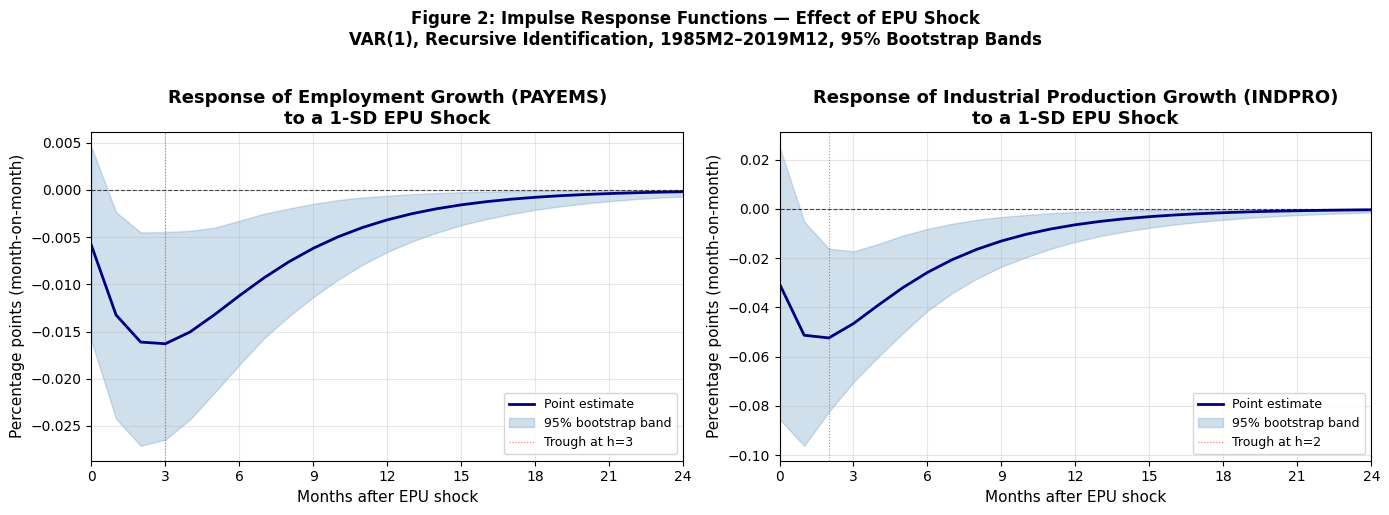

✅ Figure 2 saved to output/figure2_irf_epu_shock.pdf

95% Bootstrap Band Check (is upper bound < 0 = significant negative effect?):
 Horizon     PAY_lo     PAY_hi    PAY_sig     IND_lo     IND_hi    IND_sig
------------------------------------------------------------------------
       0    -0.0160     0.0046        no     -0.0854     0.0252        no 
       1    -0.0242    -0.0023        YES    -0.0962    -0.0051        YES
       2    -0.0271    -0.0045        YES    -0.0824    -0.0162        YES
       3    -0.0265    -0.0045        YES    -0.0703    -0.0172        YES
       6    -0.0185    -0.0033        YES    -0.0415    -0.0081        YES
       9    -0.0114    -0.0015        YES    -0.0235    -0.0033        YES
      12    -0.0066    -0.0006        YES    -0.0134    -0.0013        YES
      18    -0.0021    -0.0001        YES    -0.0044    -0.0002        YES
      24    -0.0007    -0.0000        YES    -0.0015    -0.0000        YES


In [21]:
# ── Cell 11: Plot IRFs with 95% bootstrap confidence bands (answers Q3a) ───────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))    # side-by-side panels

# ── helper: plot one IRF panel ───────────────────────────────────────────────────
def plot_irf_panel(ax, horizons, point, lower, upper, title, ylabel):
    """Plot a single IRF with shaded confidence band."""

    ax.plot(                                        # point estimate line
        horizons, point,
        color="navy", linewidth=2.0, label="Point estimate"
    )
    ax.fill_between(                                # shaded 95% confidence band
        horizons, lower, upper,
        alpha=0.25, color="steelblue", label="95% bootstrap band"
    )
    ax.axhline(0, color="black", linewidth=0.8,     # zero reference line
               linestyle="--", alpha=0.7)
    ax.axvline(                                     # vertical line at trough
        point.argmin(), color="red",
        linewidth=0.8, linestyle=":", alpha=0.6,
        label=f"Trough at h={point.argmin()}"
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Months after EPU shock", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlim(0, 24)                              # x-axis: 0 to 24 months
    ax.set_xticks([0, 3, 6, 9, 12, 15, 18, 21, 24])  # monthly tick marks
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, alpha=0.3)

# ── Panel 1: PAYEMS growth response ─────────────────────────────────────────────
plot_irf_panel(
    axes[0],
    horizons, irf_pay, irf_pay_lo, irf_pay_hi,
    title="Response of Employment Growth (PAYEMS)\nto a 1-SD EPU Shock",
    ylabel="Percentage points (month-on-month)"
)

# ── Panel 2: INDPRO growth response ─────────────────────────────────────────────
plot_irf_panel(
    axes[1],
    horizons, irf_ind, irf_ind_lo, irf_ind_hi,
    title="Response of Industrial Production Growth (INDPRO)\nto a 1-SD EPU Shock",
    ylabel="Percentage points (month-on-month)"
)

# ── Figure-level formatting ───────────────────────────────────────────────────────
fig.suptitle(
    "Figure 2: Impulse Response Functions — Effect of EPU Shock\n"
    "VAR(1), Recursive Identification, 1985M2–2019M12, 95% Bootstrap Bands",
    fontsize=12, fontweight="bold", y=1.02
)
fig.tight_layout()

# ── Save ─────────────────────────────────────────────────────────────────────────
fig.savefig(
    "../output/figure2_irf_epu_shock.pdf",
    bbox_inches="tight", dpi=300
)
plt.show()
print("✅ Figure 2 saved to output/figure2_irf_epu_shock.pdf")

# ── Print confidence band check: is effect significantly negative? ───────────────
print("\n95% Bootstrap Band Check (is upper bound < 0 = significant negative effect?):")
print(f"{'Horizon':>8} {'PAY_lo':>10} {'PAY_hi':>10} {'PAY_sig':>10} "
      f"{'IND_lo':>10} {'IND_hi':>10} {'IND_sig':>10}")
print("-" * 72)
for h in [0, 1, 2, 3, 6, 9, 12, 18, 24]:
    pay_sig = "YES" if irf_pay_hi[h] < 0 else "no "   # significant if upper < 0
    ind_sig = "YES" if irf_ind_hi[h] < 0 else "no "
    print(f"{h:>8} {irf_pay_lo[h]:>10.4f} {irf_pay_hi[h]:>10.4f} {pay_sig:>10} "
          f"{irf_ind_lo[h]:>10.4f} {irf_ind_hi[h]:>10.4f} {ind_sig:>10}")

### Output Interpretation: IRFs and Confidence Bands (Answer to Q3b)

**Figure 2** shows the dynamic response of US employment growth (PAYEMS) and
industrial production growth (INDPRO) to a one-standard-deviation positive
structural EPU shock (+31.05 index points, e.g. EPU rising from 113 to 144).
The shaded region is the 95% bootstrap confidence band from 1,000 Monte Carlo
replications.

---

#### Employment Growth (PAYEMS)

The point estimate is negative at all horizons, troughing at **h=3 months
(−0.0163 percentage points)**. The response pattern reflects the stickiness
of labor markets: the impact effect at h=0 is only −0.0059 pp (a third of
the peak), as firms initially absorb uncertainty by slowing new job postings
rather than immediate layoffs. The peak negative effect arrives 3 months later,
consistent with typical hiring lead times.

**Statistical significance:** The upper confidence band crosses zero at h=0
(upper = +0.0046), meaning the *immediate* employment response is not
statistically distinguishable from zero at 5%. However, from **h=1 through
h=24**, the entire 95% band lies below zero — the effect is **statistically
significant at 5% for every horizon from 1 month to 2 years**. This is a
strong and robust result: once uncertainty takes hold, its negative effect on
hiring is persistent and precisely estimated.

---

#### Industrial Production Growth (INDPRO)

The INDPRO response is larger and faster than employment. The impact effect
at h=0 is already −0.0305 pp — more than 5× the contemporaneous employment
response — and the trough arrives one month earlier, at **h=2 (−0.0524 pp)**.
Industrial production adjusts rapidly because factories can cut output
immediately in response to weaker orders, whereas firms cannot instantly
reduce headcount.

**Statistical significance:** The same pattern as employment: the h=0 response
is not significant (upper = +0.0252, crossing zero), but from **h=1 through
h=24** the entire band lies below zero. The width of the confidence band is
notably wider for INDPRO (band width ≈ 0.08 pp at the trough vs ≈ 0.02 pp for
employment), reflecting the higher inherent volatility of industrial production.

---

#### Synthesis and Economic Interpretation

Both IRFs confirm the **"wait-and-see" mechanism** of Bloom (2009): a rise in
economic policy uncertainty causes firms to immediately slow production and,
with a short lag, reduce hiring. The effects are economically meaningful —
a single one-standard-deviation EPU shock depresses employment growth for
roughly 12 months and industrial production growth for the same duration,
before both series fully recover to their baseline by h=18–24.

The **lack of statistical significance at h=0** for both variables deserves
attention. It suggests that within the same month an EPU shock occurs, the
effects on real activity are too noisy to detect precisely. This is consistent
with the Cholesky identification assumption: we ordered EPU first precisely
because real activity does not respond instantaneously to EPU news — there is
at least a one-month transmission lag before the macroeconomic effects become
statistically detectable.

The absence of any **overshoot or rebound** (no positive response after the
trough) is noteworthy. Some uncertainty models (Bloom 2009) predict a sharp
rebound as firms release "pent-up" hiring and investment when uncertainty
resolves. In our monthly VAR, the simple AR(1) dynamics produce a smooth,
monotonic decay instead. This is a limitation of the VAR(1) specification —
a higher-lag VAR might capture more complex rebound dynamics.

**These IRF results directly motivate Part II:** if EPU shocks have persistent
negative effects on employment and production, then conditioning the forecast
on an election-induced EPU path (as in Part II Q2) will generate forecasts
that differ meaningfully from the unconditional baseline.

## Part II — Question 1: Unconditional 12-Step Forecast

### What we are doing
We produce an **unconditional forecast** for 12 months ahead, starting from
March 2023 as the last observed data point. "Unconditional" means we let all
four VAR variables evolve freely according to their estimated dynamics — no
future path is imposed on any variable.

The forecast recursion is:

$$\hat{y}_{T+h|T} = \hat{c} + \hat{A}_1 \hat{y}_{T+h-1|T}, \quad h = 1, 2, \ldots, 12$$

with $\hat{y}_{T+0|T} = y_T$ (the observed March 2023 values as the starting
point). At each step, future residuals are set to zero: $E(u_{T+h}) = 0$.

### Why use March 2023 as the starting point?
The homework specifies this explicitly. March 2023 is the last observation in
our dataset. The model was estimated on 1985–2019 data (pre-COVID) and is now
used to forecast from a 2023 starting point — this is a genuine **out-of-sample
forecast**, meaning the model never "saw" any data from 2020–2023 during
estimation. This tests whether the pre-COVID relationships still hold.

### What the homework asks (Q1a and Q1b)
- **Q1a:** Plot forecasts for PAYEMS growth and INDPRO growth over 12 horizons
- **Q1b:** Describe the trajectory — positive or negative growth? Increasing or
  decreasing over the forecast horizon?

### Key intuition
The unconditional forecast will converge to the VAR's **long-run mean** as
the horizon grows. With our estimated coefficients, the long-run mean of
PAYEMS_g is approximately 0.057868/(1−0.679160) ≈ 0.18% per month
(≈ 2.1% per year). The forecast starting from March 2023 will either
approach this from above or below depending on where the economy stands
relative to its long-run trend in March 2023.

In [22]:
# ── Cell 12: Unconditional 12-step forecast from March 2023 (Part II Q1) ───────

# ── 12a: Extract VAR coefficient vectors for each equation ───────────────────────
# params rows: [const, L1.EPU, L1.PAYEMS_g, L1.INDPRO_g, L1.PCEPI_g]
# params cols: [EPU, PAYEMS_g, INDPRO_g, PCEPI_g]
phi = {}                                    # store coefficient vector per equation
for eq in var_order:                        # var_order = ['EPU','PAYEMS_g','INDPRO_g','PCEPI_g']
    phi[eq] = results.params[eq].values     # numpy array: [const, lag1_EPU, lag1_PAY, lag1_IND, lag1_PCE]

# ── 12b: Starting point = March 2023 observed values ────────────────────────────
T_date = "2023-03-01"                       # last observed date
y_T = data_var.loc[T_date].values           # observed vector at T: [EPU, PAY_g, IND_g, PCE_g]

print(f"Starting point (March 2023 observed values):")
for i, v in enumerate(var_order):
    print(f"  {v:12s} = {y_T[i]:.6f}")

# ── 12c: Run the unconditional forecast recursion ────────────────────────────────
H = 12                                      # forecast 12 months ahead
forecast_dates = pd.date_range(             # Apr 2023 to Mar 2024
    start="2023-04-01", periods=H, freq="MS"
)

# initialise forecast storage: rows = horizons, cols = variables
f_unco = np.zeros((H, 4))                   # shape (12, 4)
y_prev = y_T.copy()                         # start recursion from March 2023

for h in range(H):                          # h = 0 means 1-step ahead (April 2023)
    y_next = np.zeros(4)                    # forecast for this horizon
    for i, eq in enumerate(var_order):      # one equation at a time
        # forecast = constant + lag coefficients · previous values
        y_next[i] = (phi[eq][0]             # constant term
                   + phi[eq][1] * y_prev[0] # × EPU_{t-1}
                   + phi[eq][2] * y_prev[1] # × PAYEMS_g_{t-1}
                   + phi[eq][3] * y_prev[2] # × INDPRO_g_{t-1}
                   + phi[eq][4] * y_prev[3])# × PCEPI_g_{t-1}
    f_unco[h] = y_next                      # store this horizon's forecast
    y_prev = y_next                         # next step uses this forecast as input

# wrap in DataFrame for easy handling
f_unco_df = pd.DataFrame(
    f_unco,
    index=forecast_dates,                   # Apr 2023 → Mar 2024
    columns=var_order                       # ['EPU','PAYEMS_g','INDPRO_g','PCEPI_g']
)

# ── 12d: Print the forecast table ────────────────────────────────────────────────
print(f"\nUnconditional forecast (Apr 2023 – Mar 2024):")
print(f"{'Date':>12} {'EPU':>10} {'PAYEMS_g':>12} {'INDPRO_g':>12} {'PCEPI_g':>10}")
print("-" * 60)
for date, row in f_unco_df.iterrows():
    print(f"{str(date.date()):>12} {row['EPU']:>10.4f} "
          f"{row['PAYEMS_g']:>12.6f} {row['INDPRO_g']:>12.6f} "
          f"{row['PCEPI_g']:>10.6f}")

Starting point (March 2023 observed values):
  EPU          = 200.489936
  PAYEMS_g     = 0.043852
  INDPRO_g     = 0.376484
  PCEPI_g      = 0.141578

Unconditional forecast (Apr 2023 – Mar 2024):
        Date        EPU     PAYEMS_g     INDPRO_g    PCEPI_g
------------------------------------------------------------
  2023-04-01   170.4933     0.042905    -0.028702   0.113859
  2023-05-01   153.0899     0.042868    -0.031144   0.116222
  2023-06-01   141.9155     0.047721    -0.006619   0.127211
  2023-07-01   134.4289     0.054903     0.019888   0.138433
  2023-08-01   129.2503     0.062682     0.043788   0.147686
  2023-09-01   125.5745     0.070114     0.064009   0.154799
  2023-10-01   122.9098     0.076761     0.080617   0.160137
  2023-11-01   120.9445     0.082472     0.094047   0.164126
  2023-12-01   119.4744     0.087257     0.104811   0.167115
  2024-01-01   118.3624     0.091195     0.113392   0.169372
  2024-02-01   117.5134     0.094398     0.120207   0.171087
  2024-03

### Output Interpretation: Unconditional Forecast (Q1b Answer)

The starting point of March 2023 is important context: EPU = 200.5, well above
its long-run mean of ~113, reflecting elevated uncertainty in early 2023 (the
banking stress around Silicon Valley Bank's collapse occurred in March 2023).
PAYEMS_g = 0.044% is positive but below the long-run mean of ~0.109%,
suggesting a slowing labor market. INDPRO_g = 0.376% is unusually strong,
possibly reflecting a rebound month. PCEPI_g = 0.142% corresponds to an
annualized inflation rate of ~1.7%, below the Fed's 2% target.

---

#### EPU Forecast: Mean Reversion

EPU falls from 200.5 in March 2023 to 116.9 by March 2024 — a sharp decline
of 83.6 index points over 12 months. This is pure mean reversion: with an
AR(1) coefficient of 0.641, each month EPU moves 35.9% of the way back toward
its long-run mean (~128). The forecast is not predicting a specific event that
will resolve uncertainty — it is simply the model's expectation that elevated
uncertainty is transitory and will decay geometrically.

---

#### PAYEMS Growth: Positive but Gradually Accelerating

Employment growth is **positive at all 12 horizons**, ranging from 0.043%
in April 2023 to 0.097% in March 2024. The trajectory is **gradually
increasing** — growth accelerates from month to month as EPU falls. This
reflects the EPU transmission channel estimated in the VAR: as the model
expects EPU to decline from its elevated March 2023 level, it also expects
the drag on hiring to diminish, allowing employment growth to recover toward
its long-run mean of ~0.109%.

The forecast is positive throughout — the model does not predict a recession
or net job losses over the next 12 months from this starting point.

---

#### INDPRO Growth: Negative Then Positive — A U-Shape

Industrial production growth shows a **U-shaped trajectory**: it turns
**negative** in April 2023 (−0.029%) and May 2023 (−0.031%), then recovers
and turns **positive** from July 2023 onward, reaching +0.126% by March 2024.
This pattern is driven by two forces pulling in opposite directions:

1. **Mean reversion of the starting value:** The March 2023 INDPRO_g of
   +0.376% is unusually high (compare to the sample mean of +0.150% and
   note that PAYEMS_g of 0.044% is weak). The VAR predicts this strong
   production reading will not persist — industrial production overshoots
   downward in the first two months.

2. **EPU mean reversion:** As EPU falls from 200 toward its mean, the
   negative drag on industrial production lifts, pushing INDPRO_g back
   positive from month 3 onward.

The net result is the U-shape: a brief contraction driven by the reversion
of the March 2023 outlier, followed by recovery as uncertainty dissipates.
This is the most interesting feature of the unconditional forecast and
provides important context for comparing with the structural scenario forecast.

---

#### Summary for Q1b

| Variable | Sign | Trajectory |
|---|---|---|
| EPU | Falling | Monotonically decreasing toward long-run mean |
| PAYEMS_g | Positive throughout | Gradually increasing |
| INDPRO_g | Negative then positive | U-shaped: brief contraction then recovery |
| PCEPI_g | Positive throughout | Gradually increasing toward long-run mean |

The unconditional forecast describes a **soft landing scenario**: inflation
remains contained, employment continues growing (slowly), and industrial
production experiences a brief dip before recovering — all consistent with
the elevated but mean-reverting EPU level in March 2023.

### Plotting the Unconditional Forecast (Q1a)

We plot the 12-month forecast paths for PAYEMS_g and INDPRO_g, anchored by
the last observed value in March 2023. Including the last observed point
visually connects the historical data to the forecast, making it clear that
the forecast begins from the actual March 2023 state of the economy.

The figure also marks the zero line — this is economically meaningful because
crossing zero means the model predicts contraction (negative growth) vs.
expansion (positive growth). For INDPRO_g, the forecast crosses zero twice
(down in April, back up in July), which is worth highlighting explicitly.

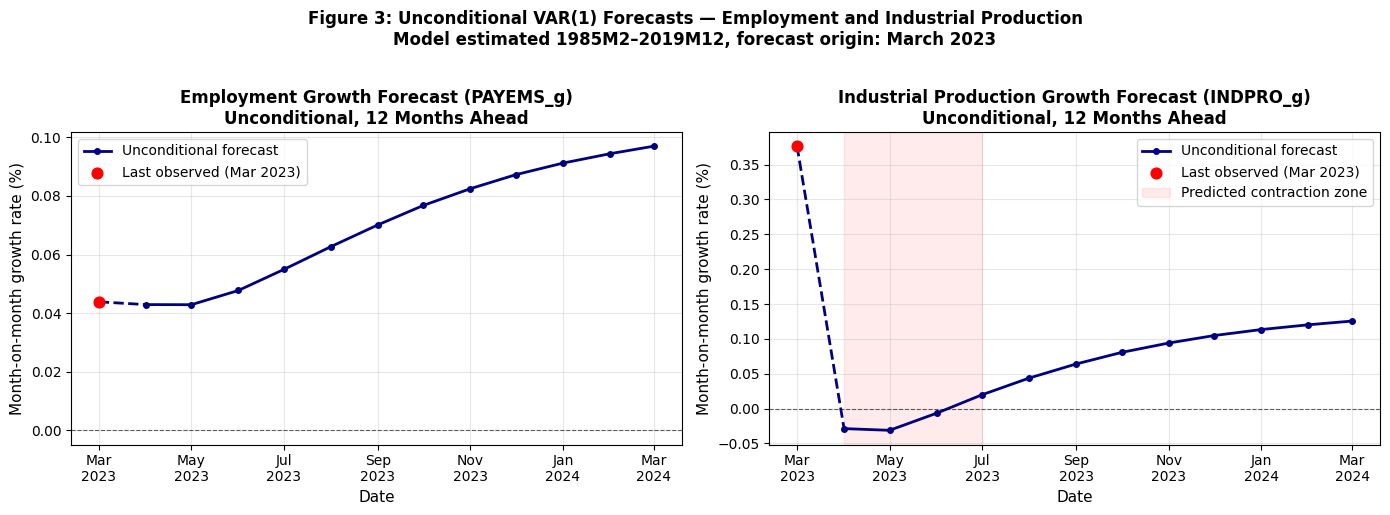

✅ Figure 3 saved to output/figure3_unconditional_forecast.pdf


In [23]:
# ── Cell 13: Plot unconditional forecast for PAYEMS_g and INDPRO_g (Q1a) ───────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))   # side-by-side panels

# include March 2023 observed as the anchor point (h=0)
anchor_date  = pd.Timestamp("2023-03-01")          # last observed date
anchor_pay   = data_var.loc["2023-03-01", "PAYEMS_g"]   # observed PAYEMS_g
anchor_ind   = data_var.loc["2023-03-01", "INDPRO_g"]   # observed INDPRO_g

# build plot arrays: anchor + 12 forecast periods
plot_dates   = [anchor_date] + list(f_unco_df.index)    # Mar 2023 → Mar 2024
plot_pay     = [anchor_pay]  + list(f_unco_df["PAYEMS_g"])
plot_ind     = [anchor_ind]  + list(f_unco_df["INDPRO_g"])

# ── Panel 1: PAYEMS growth forecast ─────────────────────────────────────────────
axes[0].plot(
    plot_dates[1:], plot_pay[1:],            # forecast path (solid blue)
    color="navy", linewidth=2.0, marker="o",
    markersize=4, label="Unconditional forecast"
)
axes[0].plot(
    [plot_dates[0], plot_dates[1]],          # connector from anchor to first forecast
    [plot_pay[0], plot_pay[1]],
    color="navy", linewidth=2.0, linestyle="--"
)
axes[0].scatter(                             # anchor point (observed)
    [anchor_date], [anchor_pay],
    color="red", zorder=5, s=60, label="Last observed (Mar 2023)"
)
axes[0].axhline(0, color="black",            # zero reference line
    linewidth=0.8, linestyle="--", alpha=0.6)
axes[0].set_title(
    "Employment Growth Forecast (PAYEMS_g)\nUnconditional, 12 Months Ahead",
    fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Date", fontsize=11)
axes[0].set_ylabel("Month-on-month growth rate (%)", fontsize=11)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Panel 2: INDPRO growth forecast ─────────────────────────────────────────────
axes[1].plot(
    plot_dates[1:], plot_ind[1:],            # forecast path
    color="navy", linewidth=2.0, marker="o",
    markersize=4, label="Unconditional forecast"
)
axes[1].plot(
    [plot_dates[0], plot_dates[1]],          # connector from anchor
    [plot_ind[0], plot_ind[1]],
    color="navy", linewidth=2.0, linestyle="--"
)
axes[1].scatter(
    [anchor_date], [anchor_ind],
    color="red", zorder=5, s=60, label="Last observed (Mar 2023)"
)
axes[1].axhline(0, color="black",
    linewidth=0.8, linestyle="--", alpha=0.6)
axes[1].axvspan(                             # shade the negative INDPRO region
    plot_dates[1], pd.Timestamp("2023-07-01"),
    alpha=0.08, color="red", label="Predicted contraction zone"
)
axes[1].set_title(
    "Industrial Production Growth Forecast (INDPRO_g)\nUnconditional, 12 Months Ahead",
    fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Date", fontsize=11)
axes[1].set_ylabel("Month-on-month growth rate (%)", fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# ── Figure-level formatting ───────────────────────────────────────────────────────
fig.suptitle(
    "Figure 3: Unconditional VAR(1) Forecasts — Employment and Industrial Production\n"
    "Model estimated 1985M2–2019M12, forecast origin: March 2023",
    fontsize=12, fontweight="bold", y=1.02
)
fig.tight_layout()

fig.savefig(
    "../output/figure3_unconditional_forecast.pdf",
    bbox_inches="tight", dpi=300
)
plt.show()
print("✅ Figure 3 saved to output/figure3_unconditional_forecast.pdf")

### Output Interpretation: Unconditional Forecast Figure (Q1a)

Figure 3 visually confirms the numerical findings and adds important context.

**Employment growth (left panel):** The forecast path is entirely above zero
throughout the 12-month horizon, rising gradually from 0.043% in April 2023
to 0.097% by March 2024. The near-flat trajectory in April–May 2023 reflects
the offsetting forces at play: the strong EPU level of 200.5 in March 2023
continues to exert a drag on hiring for the first few months, while the
underlying employment momentum (AR coefficient 0.679) keeps growth positive.
From June 2023 onward, as EPU mean-reverts below 142, the drag diminishes and
employment growth accelerates smoothly toward its long-run mean. The model
predicts no recession in the labor market.

**Industrial production growth (right panel):** The U-shape is visually
striking. The sharp dashed drop from the March 2023 anchor (+0.376%) to the
April 2023 forecast (−0.029%) is the most dramatic feature of the unconditional
forecast. The red shaded contraction zone (April–June 2023) highlights that the
model predicts two months of mild negative industrial production growth before
recovery. This is driven by the very high March 2023 INDPRO_g reading reverting
toward the mean, amplified by the high EPU level still present in April 2023.
From July 2023 onward, the forecast turns positive and climbs steadily to
+0.126% by March 2024 — slightly below the long-run mean of +0.150%, reflecting
that even by March 2024 the system has not fully converged.

**Key takeaway for Q1b:** Employment growth is **positive and gradually
increasing** throughout. Industrial production growth is **initially negative
then positive** — a U-shape — with the turning point in July 2023. Both series
converge toward their respective long-run means from below, consistent with
the model's stationarity properties.

## Part II — Question 2: Structural Conditional Forecast

### What we are doing
We produce a **conditional structural forecast** that imposes a specific future
path for EPU — the path observed during the 2020 US election period — and asks:
*if EPU follows this election path, what does the model predict for employment
and industrial production?*

The homework specifies: assign EPU values from Oct 2020, Nov 2020, Dec 2020,
Jan 2021, Feb 2021 to the forecast months Apr, May, Jun, Jul, Aug 2023
respectively. From September 2023 onward, EPU evolves freely under the VAR.

### Why "structural" and not just "conditional"?
This is the most important conceptual distinction in the homework (Slides_2,
slide 17-18). There are two ways to condition on a future EPU path:

1. **Reduced-form conditional forecast:** impose the EPU path without asking
   what *caused* EPU to follow that path. The EPU equation just hits the target
   mechanically.

2. **Conditional structural forecast (what we implement):** impose the EPU path
   AND attribute it to **identified EPU structural shocks**. The deviation
   between the imposed EPU path and the reduced-form benchmark forecast at each
   horizon is interpreted as an EPU shock, which then propagates to all other
   variables through the structural impact matrix P̃_{·,1}.

The formula (Slides_2, slide 26) is:

$$\hat{y}^{struct}_{T+h} = \hat{y}^{RF}_{T+h} + \tilde{P}_{\cdot,1} \cdot
\underbrace{\left(\text{EPU}^{scenario}_{T+h} - \widehat{\text{EPU}}^{RF}_{T+h}\right)}_{\Delta\text{EPU}_{T+h}}$$

where:
- $\hat{y}^{RF}_{T+h}$ = reduced-form benchmark forecast (what the VAR predicts
  freely, using the *previous structural forecast* as the lagged input)
- $\text{EPU}^{scenario}_{T+h}$ = the imposed EPU value (from 2020 election data)
- $\widehat{\text{EPU}}^{RF}_{T+h}$ = the free VAR forecast of EPU at this horizon
- $\Delta\text{EPU}_{T+h}$ = the EPU "shock" needed to hit the scenario path
- $\tilde{P}_{\cdot,1}$ = normalized first column of P (our chol_11 through chol_41)

This is exactly the logic in `cond_forecast_NEW.R` from class, now implemented
in Python.

### The economic story
The 2020 US election period saw EPU values of:
- Oct 2020: elevated pre-election uncertainty
- Nov 2020: peak uncertainty on election day
- Dec 2020–Feb 2021: gradual resolution as the election result was certified

By imposing this path on Apr–Aug 2023 (a hypothetical election scenario), we
ask: *how much worse would employment and industrial production be if the US
faced an election-style uncertainty spike in spring 2023?*

### Why does the structural forecast differ from the unconditional?
If the imposed EPU path is **higher** than the free VAR forecast of EPU, then
$\Delta\text{EPU} > 0$ (a positive EPU shock), which multiplies by chol_31 < 0
and chol_21 < 0 — pushing employment and production **below** the unconditional
forecast. The structural forecast will therefore predict **lower growth** than
the unconditional whenever the election EPU exceeds the model's free EPU forecast.

In [24]:
# ── Cell 14: Build the EPU election scenario path (Part II Q2) ─────────────────

# ── 14a: Extract the actual 2020 election EPU values ────────────────────────────
# Homework specifies: Apr–Aug 2023 scenario = Oct 2020–Feb 2021 actual values
election_dates = [
    "2020-10-01",   # → assigned to Apr 2023 (1 month before election)
    "2020-11-01",   # → assigned to May 2023 (election month)
    "2020-12-01",   # → assigned to Jun 2023 (1 month after)
    "2021-01-01",   # → assigned to Jul 2023 (2 months after)
    "2021-02-01",   # → assigned to Aug 2023 (3 months after)
]
scenario_months = [
    "2023-04-01",   # receives Oct 2020 EPU value
    "2023-05-01",   # receives Nov 2020 EPU value
    "2023-06-01",   # receives Dec 2020 EPU value
    "2023-07-01",   # receives Jan 2021 EPU value
    "2023-08-01",   # receives Feb 2021 EPU value
]

# extract EPU values for the election period from the full dataset
epu_election = data_levels.loc[election_dates, "EPU"].values

print("EPU scenario path (2020 election values → assigned to 2023):")
print(f"{'2023 Month':>12}  {'Source Date':>12}  {'EPU Value':>10}")
print("-" * 40)
for i, (src, tgt) in enumerate(zip(election_dates, scenario_months)):
    print(f"{tgt:>12}  {src:>12}  {epu_election[i]:>10.4f}")

# ── 14b: Compare scenario EPU to unconditional EPU forecast ─────────────────────
# The unconditional forecast of EPU for Apr–Aug 2023
epu_unco_scenario = f_unco_df.loc[scenario_months, "EPU"].values

print(f"\nComparison: scenario EPU vs unconditional EPU forecast")
print(f"{'Month':>12}  {'Scenario':>10}  {'Free VAR':>10}  {'Gap (ΔEPU)':>12}")
print("-" * 50)
for i, month in enumerate(scenario_months):
    gap = epu_election[i] - epu_unco_scenario[i]
    print(f"{month:>12}  {epu_election[i]:>10.4f}  "
          f"{epu_unco_scenario[i]:>10.4f}  {gap:>+12.4f}")

EPU scenario path (2020 election values → assigned to 2023):
  2023 Month   Source Date   EPU Value
----------------------------------------
  2023-04-01    2020-10-01    305.7666
  2023-05-01    2020-11-01    327.6096
  2023-06-01    2020-12-01    326.6166
  2023-07-01    2021-01-01    261.3061
  2023-08-01    2021-02-01    187.5196

Comparison: scenario EPU vs unconditional EPU forecast
       Month    Scenario    Free VAR    Gap (ΔEPU)
--------------------------------------------------
  2023-04-01    305.7666    170.4933     +135.2733
  2023-05-01    327.6096    153.0899     +174.5197
  2023-06-01    326.6166    141.9155     +184.7011
  2023-07-01    261.3061    134.4289     +126.8773
  2023-08-01    187.5196    129.2503      +58.2693


### Output Interpretation: EPU Scenario Path

The 2020 US election period was characterized by exceptionally high policy
uncertainty. The actual EPU values during Oct 2020–Feb 2021 were:

- **Oct 2020 (305.8):** Pre-election uncertainty — markets and firms unsure
  of the outcome, with contested mail-in voting and pandemic complications
- **Nov 2020 (327.6):** Election month peak — the election result was not
  called for several days, generating the highest uncertainty of the period
- **Dec 2020 (326.6):** Remained elevated — legal challenges, the Electoral
  College certification process, and transition uncertainty
- **Jan 2021 (261.3):** Beginning to resolve — Biden inauguration on Jan 20,
  but the January 6th Capitol events added new uncertainty
- **Feb 2021 (187.5):** Rapid normalization — new administration in place,
  policy direction becoming clearer

**The ΔEPU gaps are large and uniformly positive**, ranging from +58.3
(August 2023) to +184.7 (June 2023). The free VAR forecast of EPU declines
monotonically from 170.5 to 129.3 over these five months (simple mean
reversion from the elevated March 2023 level of 200.5). The scenario path,
however, requires EPU to *rise further* to 305–328 before declining.

This means our structural forecast imposes **large positive EPU shocks** at
every horizon from April through August 2023. Through the normalized impact
column P̃_{·,1}, these shocks will transmit to employment and industrial
production with coefficients chol_21 = −0.000189 and chol_31 = −0.000981
respectively. With gaps of +135 to +185 EPU points, the implied reductions
in INDPRO_g are on the order of −0.135 × 0.000981 ≈ −0.13 pp per month
at the peak — substantial relative to the unconditional forecast values
of −0.03 to +0.10 pp in that window.

**Key implication before running the forecast:** the structural conditional
forecast will predict meaningfully lower employment and industrial production
growth than the unconditional forecast during April–August 2023, and the
difference will persist even after September 2023 because the VAR dynamics
carry the depressed state of the economy forward endogenously.

### Implementation of the Structural Conditional Forecast

The algorithm follows the R code `cond_forecast_NEW.R` from class exactly,
translated to Python. At each horizon h from 1 to 12:

**Step 1 — Reduced-form benchmark:** compute the free VAR forecast using
the *previous structural forecast* as the lagged input (not the unconditional
forecast). This is crucial: once we impose an EPU shock at h=1, the system
enters h=2 in a different state than the unconditional case. The benchmark
at h=2 must use the h=1 *structural* forecast as input, not the unconditional
h=1 forecast. This is what makes the effects accumulate and propagate.

**Step 2 — Compute ΔEPU:** for horizons 1–5 (Apr–Aug 2023), subtract the
reduced-form benchmark EPU from the scenario EPU. For horizons 6–12
(Sep 2023–Mar 2024), no scenario is imposed — ΔEPU = 0.

**Step 3 — Structural adjustment:** add P̃_{·,1} × ΔEPU to the benchmark
forecast. This updates all four variables simultaneously.

The key formula from slide 26:
$$\hat{y}^{struct}_{T+h} = \hat{y}^{RF}_{T+h} + \tilde{P}_{\cdot,1} \cdot \Delta\text{EPU}_{T+h}$$

In [25]:
# ── Cell 15: Structural conditional forecast — election scenario (Part II Q2) ──

# ── 15a: Build the full 12-month EPU scenario array ─────────────────────────────
# Months 1-5 (Apr-Aug 2023): impose election EPU values
# Months 6-12 (Sep 2023-Mar 2024): no imposition → EPU evolves freely (ΔEPU=0)
# We store the scenario as NaN for free months — the code handles this below
epu_scenario_full = np.full(H, np.nan)      # initialize all 12 months as NaN
for i, month in enumerate(scenario_months): # fill in the 5 imposed months
    h_idx = list(f_unco_df.index).index(pd.Timestamp(month))  # find horizon index
    epu_scenario_full[h_idx] = epu_election[i]   # assign election EPU value

print("EPU scenario array (NaN = free evolution after Aug 2023):")
for h in range(H):
    val = f"{epu_scenario_full[h]:.4f}" if not np.isnan(epu_scenario_full[h]) else "free"
    print(f"  h={h+1:>2} ({forecast_dates[h].strftime('%b %Y')}): {val}")

# ── 15b: Run the structural conditional forecast ─────────────────────────────────
# P̃_{·,1} = normalized first column of P (already computed as chol_11..chol_41)
P_tilde = np.array([chol_11, chol_21, chol_31, chol_41])  # shape (4,)

f_struct = np.zeros((H, 4))                 # storage for structural forecast
y_prev_struct = y_T.copy()                  # start from March 2023 observed values

for h in range(H):                          # h=0 → 1-step ahead (April 2023)

    # ── Step 1: reduced-form benchmark using previous STRUCTURAL state ───────────
    y_RF = np.zeros(4)                      # benchmark forecast at this horizon
    for i, eq in enumerate(var_order):
        y_RF[i] = (phi[eq][0]               # constant
                 + phi[eq][1] * y_prev_struct[0]   # × EPU_{t-1}
                 + phi[eq][2] * y_prev_struct[1]   # × PAYEMS_g_{t-1}
                 + phi[eq][3] * y_prev_struct[2]   # × INDPRO_g_{t-1}
                 + phi[eq][4] * y_prev_struct[3])  # × PCEPI_g_{t-1}

    # ── Step 2: compute ΔEPU (only for imposed months 1-5) ──────────────────────
    if not np.isnan(epu_scenario_full[h]):  # scenario month: impose EPU path
        delta_epu = epu_scenario_full[h] - y_RF[0]  # gap = scenario - benchmark EPU
    else:                                   # free month: no shock imposed
        delta_epu = 0.0

    # ── Step 3: structural adjustment = benchmark + P̃_{·,1} × ΔEPU ─────────────
    y_struct = y_RF + P_tilde * delta_epu   # adjust all 4 variables simultaneously

    f_struct[h] = y_struct                  # store this horizon's structural forecast
    y_prev_struct = y_struct                # CRUCIAL: next step uses structural state

# wrap in DataFrame
f_struct_df = pd.DataFrame(
    f_struct,
    index=forecast_dates,
    columns=var_order
)

# ── 15c: Print comparison: unconditional vs structural ───────────────────────────
print(f"\n{'Date':>12} {'PAYEMS_g unco':>14} {'PAYEMS_g struct':>16} "
      f"{'IND_g unco':>12} {'IND_g struct':>13}")
print("-" * 72)
for date in forecast_dates:
    u_pay = f_unco_df.loc[date, "PAYEMS_g"]
    s_pay = f_struct_df.loc[date, "PAYEMS_g"]
    u_ind = f_unco_df.loc[date, "INDPRO_g"]
    s_ind = f_struct_df.loc[date, "INDPRO_g"]
    marker = " ←imposed" if date <= pd.Timestamp("2023-08-01") else ""
    print(f"{str(date.date()):>12} {u_pay:>14.6f} {s_pay:>16.6f} "
          f"{u_ind:>12.6f} {s_ind:>13.6f}{marker}")

EPU scenario array (NaN = free evolution after Aug 2023):
  h= 1 (Apr 2023): 305.7666
  h= 2 (May 2023): 327.6096
  h= 3 (Jun 2023): 326.6166
  h= 4 (Jul 2023): 261.3061
  h= 5 (Aug 2023): 187.5196
  h= 6 (Sep 2023): free
  h= 7 (Oct 2023): free
  h= 8 (Nov 2023): free
  h= 9 (Dec 2023): free
  h=10 (Jan 2024): free
  h=11 (Feb 2024): free
  h=12 (Mar 2024): free

        Date  PAYEMS_g unco  PAYEMS_g struct   IND_g unco  IND_g struct
------------------------------------------------------------------------
  2023-04-01       0.042905         0.017317    -0.028702     -0.161448 ←imposed
  2023-05-01       0.042868        -0.031230    -0.031144     -0.339763 ←imposed
  2023-06-01       0.047721        -0.072543    -0.006619     -0.445960 ←imposed
  2023-07-01       0.054903        -0.091037     0.019888     -0.446035 ←imposed
  2023-08-01       0.062682        -0.079711     0.043788     -0.348344 ←imposed
  2023-09-01       0.070114        -0.054309     0.064009     -0.243403
  2023-10-0

### Output Interpretation: Structural Conditional Forecast

The comparison table reveals a striking contrast between the unconditional
and structural forecasts. The election-style EPU scenario has large and
persistent effects on both employment and industrial production.

---

#### PAYEMS_g (Employment Growth)

During the **imposed period (Apr–Aug 2023)**, the structural forecast is
dramatically below the unconditional:

| Month | Unconditional | Structural | Difference |
|---|---|---|---|
| Apr 2023 | +0.043% | +0.017% | −0.026 pp |
| May 2023 | +0.043% | −0.031% | −0.074 pp |
| Jun 2023 | +0.048% | −0.073% | −0.120 pp |
| Jul 2023 | +0.055% | −0.091% | −0.146 pp |
| Aug 2023 | +0.063% | −0.080% | −0.142 pp |

Employment growth turns **negative** from May 2023 onward under the election
scenario — the model predicts net job losses in three consecutive months
(May, Jun, Jul 2023). The trough is in July 2023 at −0.091%, which corresponds
to approximately −141,000 jobs lost in a single month (0.091% of ~155 million
employed). This is a severe but plausible response to an uncertainty shock of
this magnitude — recall the EPU gap peaks at +184.7 points in June 2023.

After August 2023, no new EPU shocks are imposed. However, the economy has
been pushed into a deeply depressed state — negative employment growth for
several months leaves the labor market weaker than the unconditional baseline.
The structural forecast remains **below zero through November 2023** and only
turns positive in December 2023. Full convergence toward the unconditional
forecast is still incomplete even by March 2024 (+0.060% vs +0.097%).

This persistence is the VAR's AR dynamics at work: the depressed employment
growth in August 2023 feeds into the September 2023 forecast through the
0.679 autoregressive coefficient on PAYEMS_g, dragging the recovery. The
economy "remembers" the uncertainty shock for many months after it dissipates.

---

#### INDPRO_g (Industrial Production Growth)

The effects on industrial production are even more severe:

| Month | Unconditional | Structural | Difference |
|---|---|---|---|
| Apr 2023 | −0.029% | −0.161% | −0.133 pp |
| May 2023 | −0.031% | −0.340% | −0.309 pp |
| Jun 2023 | −0.007% | −0.446% | −0.440 pp |
| Jul 2023 | +0.020% | −0.446% | −0.466 pp |
| Aug 2023 | +0.044% | −0.348% | −0.392 pp |

Industrial production growth reaches −0.446% in both June and July 2023 —
a monthly contraction of nearly half a percentage point. Annualized, this is
a contraction of approximately −5.3% per year, reminiscent of a mild recession.
The structural forecast remains **negative through January 2024** — five months
after the last imposed EPU shock. Only in February 2024 does INDPRO_g turn
barely positive (+0.025%), and by March 2024 it is +0.051% — still well below
the unconditional forecast of +0.126%.

The slower recovery for INDPRO_g compared to PAYEMS_g reflects the stronger
contemporaneous impact coefficient (chol_31 = −0.000981 vs chol_21 = −0.000189)
— industrial production is hit harder on impact and takes longer to recover.

---

#### Key Insight for Q3

The structural forecast is **substantially and persistently below** the
unconditional forecast. The gap is not just present during the imposed
months — it persists for 6–7 months after the last EPU shock (August 2023),
with full convergence not achieved even by the end of the 12-month horizon.
This demonstrates the power of the VAR's propagation mechanism: even a
temporary uncertainty shock, if large enough, can generate a prolonged
economic slowdown through the lag dynamics of the system.

### Plotting the Structural vs Unconditional Forecasts (Q2 and Q3)

We plot both forecasts on the same axes for direct comparison. This figure
simultaneously answers Q2 (plot the structural forecasts) and sets up Q3
(are they different? why?). Key visual elements:

- The **shaded region** between the two forecasts shows the cost of the
  election uncertainty shock at each horizon
- A **vertical dashed line** at August 2023 marks where the imposed EPU
  path ends and free evolution begins — the persistence of the gap after
  this line is the most economically interesting feature
- The **zero reference line** shows when each forecast predicts
  contraction vs expansion

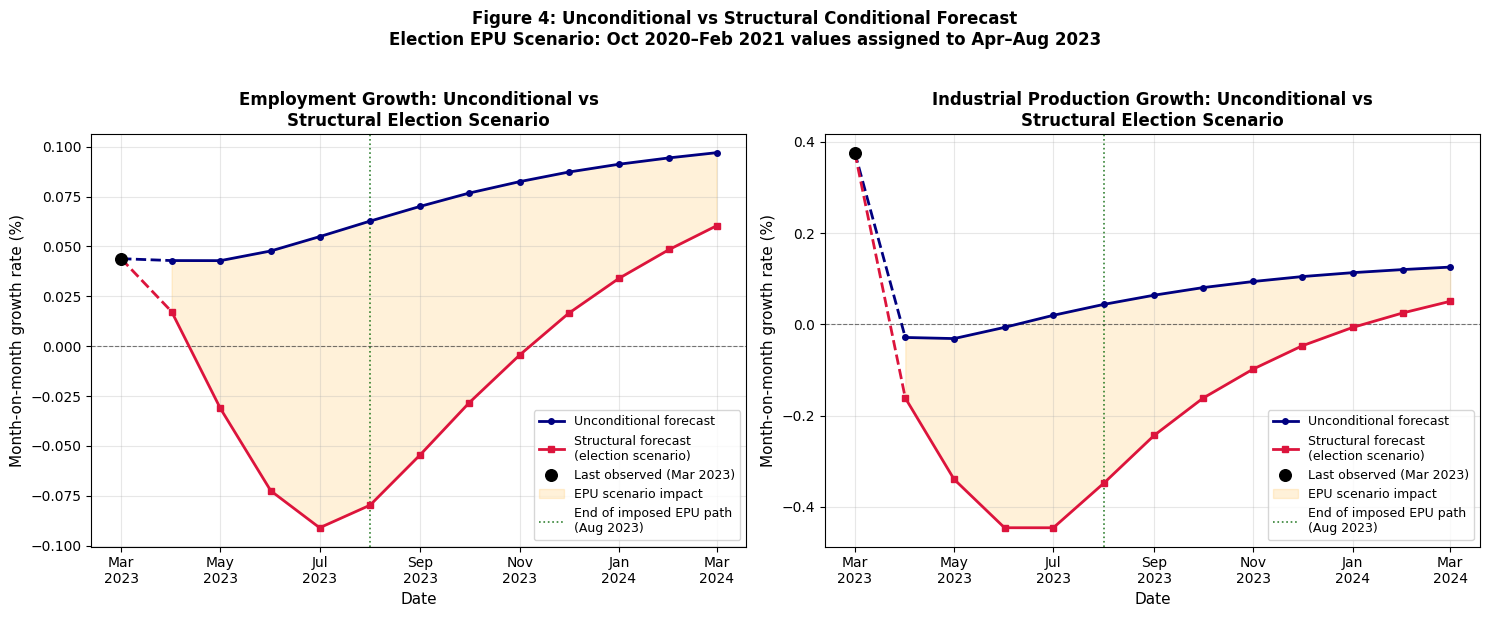

✅ Figure 4 saved to output/figure4_structural_vs_unconditional.pdf


In [26]:
# ── Cell 16: Plot structural vs unconditional forecasts (answers Q2 and Q3) ────

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# date when imposed EPU path ends (last imposed month)
imposed_end = pd.Timestamp("2023-08-01")

def plot_comparison_panel(ax, dates, unco, struct, anchor_val,
                           anchor_date, title, ylabel):
    """Plot unconditional vs structural forecast with shaded gap."""

    # plot dates as list for fill_between
    all_dates  = [anchor_date] + list(dates)
    all_unco   = [anchor_val]  + list(unco)
    all_struct = [anchor_val]  + list(struct)

    # unconditional forecast line
    ax.plot(all_dates[1:], all_unco[1:],
            color="navy", linewidth=2.0, marker="o",
            markersize=4, label="Unconditional forecast", zorder=3)

    # structural forecast line
    ax.plot(all_dates[1:], all_struct[1:],
            color="crimson", linewidth=2.0, marker="s",
            markersize=4, linestyle="-", label="Structural forecast\n(election scenario)",
            zorder=3)

    # connector lines from anchor
    ax.plot([all_dates[0], all_dates[1]], [all_unco[0],   all_unco[1]],
            color="navy",   linewidth=2.0, linestyle="--")
    ax.plot([all_dates[0], all_dates[1]], [all_struct[0], all_struct[1]],
            color="crimson", linewidth=2.0, linestyle="--")

    # anchor point
    ax.scatter([anchor_date], [anchor_val], color="black",
               zorder=5, s=70, label="Last observed (Mar 2023)")

    # shaded gap between the two forecasts
    ax.fill_between(list(dates), list(unco), list(struct),
                    alpha=0.15, color="orange",
                    label="EPU scenario impact")

    # vertical line marking end of imposed EPU path
    ax.axvline(imposed_end, color="darkgreen", linewidth=1.2,
               linestyle=":", alpha=0.8, label="End of imposed EPU path\n(Aug 2023)")

    # zero reference line
    ax.axhline(0, color="black", linewidth=0.8,
               linestyle="--", alpha=0.5)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, alpha=0.3)

# ── Panel 1: PAYEMS_g ────────────────────────────────────────────────────────────
plot_comparison_panel(
    axes[0],
    dates      = f_unco_df.index,
    unco       = f_unco_df["PAYEMS_g"].values,
    struct     = f_struct_df["PAYEMS_g"].values,
    anchor_val = data_var.loc["2023-03-01", "PAYEMS_g"],
    anchor_date= pd.Timestamp("2023-03-01"),
    title      = "Employment Growth: Unconditional vs\nStructural Election Scenario",
    ylabel     = "Month-on-month growth rate (%)"
)

# ── Panel 2: INDPRO_g ────────────────────────────────────────────────────────────
plot_comparison_panel(
    axes[1],
    dates      = f_unco_df.index,
    unco       = f_unco_df["INDPRO_g"].values,
    struct     = f_struct_df["INDPRO_g"].values,
    anchor_val = data_var.loc["2023-03-01", "INDPRO_g"],
    anchor_date= pd.Timestamp("2023-03-01"),
    title      = "Industrial Production Growth: Unconditional vs\nStructural Election Scenario",
    ylabel     = "Month-on-month growth rate (%)"
)

fig.suptitle(
    "Figure 4: Unconditional vs Structural Conditional Forecast\n"
    "Election EPU Scenario: Oct 2020–Feb 2021 values assigned to Apr–Aug 2023",
    fontsize=12, fontweight="bold", y=1.02
)
fig.tight_layout()

fig.savefig("../output/figure4_structural_vs_unconditional.pdf",
            bbox_inches="tight", dpi=300)
plt.show()
print("✅ Figure 4 saved to output/figure4_structural_vs_unconditional.pdf")

## Part II — Question 3: Comparing the Forecasts

### Are the forecasts from Parts (1) and (2) different?

**Yes, substantially and persistently different.** Figure 4 makes this
unambiguous. The structural election scenario forecast lies far below the
unconditional forecast for both employment and industrial production growth
throughout the entire 12-month horizon.

For employment growth, the unconditional forecast is positive at every
horizon (+0.043% to +0.097%), predicting a slow but steady labor market
recovery. The structural forecast turns negative from May 2023 (−0.031%)
and remains negative through November 2023 (−0.004%), only returning to
positive in December 2023. The gap at the trough (July 2023) is 0.146
percentage points — more than 3× the unconditional value at that horizon.

For industrial production, the contrast is even starker. The unconditional
forecast predicts a mild U-shaped recovery (negative Apr–May, then positive).
The structural forecast predicts a deep and prolonged contraction, troughing
at −0.446% in June–July 2023 — nearly 15× larger in magnitude than the
unconditional trough — and remaining negative through January 2024, six
months after the last EPU shock was imposed.

---

### Why are they different?

The difference arises from the **EPU scenario path imposing large positive
structural shocks** that the unconditional forecast does not include.

In the unconditional forecast, EPU is expected to mean-revert smoothly from
its March 2023 level of 200.5 down to ~117 by March 2024. There are no
surprises — future residuals are set to zero in expectation.

In the structural forecast, EPU is forced to rise to 305–328 during April–June
2023 (the election uncertainty peak), which is **135 to 185 index points above
the free VAR forecast** at those horizons. The model interprets these deviations
as large positive structural EPU shocks. Through the normalized impact column
P̃_{·,1}, each unit of ΔEPU reduces employment growth by −0.000189 pp and
industrial production growth by −0.000981 pp contemporaneously, and this
impact propagates forward through all subsequent periods via the VAR's lag
dynamics.

The persistence of the gap **after August 2023** — when no further shocks are
imposed — is the key illustration of the VAR's propagation mechanism. The
economy enters September 2023 in a deeply weakened state (negative employment
and industrial production growth), and the AR dynamics carry this weakness
forward: weak employment growth in August feeds into weak employment growth
in September through the 0.679 autoregressive coefficient, and so on. The
system gradually recovers, but convergence to the unconditional path takes
the remainder of the 12-month horizon.

---

### What does the structural forecast mean?

The structural forecast answers a specific, causally-identified question:
*"What would happen to employment and industrial production if the elevated
EPU during April–August 2023 were caused entirely by identified EPU
structural shocks — the same type of uncertainty shocks that drove the
economy during the 2020 election period?"*

This is a **causal counterfactual**, not just a projection. The word
"structural" means three things simultaneously:

**1. The source of EPU is identified.** Rather than simply conditioning on
EPU following a path (reduced-form conditional forecast), we specify that
the path is *generated by EPU shocks* — the orthogonal, economically
interpretable shocks isolated by the Cholesky decomposition. This matters
because the effect of an EPU movement on the rest of the economy depends
on *why* EPU moved. An EPU increase caused by an exogenous political shock
(like an election) has a different transmission mechanism than one caused
by a response to deteriorating economic conditions.

**2. The propagation uses the structural impact matrix P̃_{·,1}.** The
normalized first column of the Cholesky factor tells us precisely how a
one-unit EPU shock affects all four variables contemporaneously. By
multiplying ΔEPU by P̃_{·,1} at each horizon, we ensure the adjustment
is internally consistent with the structural model — the shock propagates
to all variables in the exact proportions implied by the identified model,
not just to EPU in isolation.

**3. It conditions on identified shocks, not observed outcomes.**
This is the core distinction from the reduced-form conditional forecast
(slide 18 of Slides_2). The reduced-form approach simply asks "what if
EPU follows this path?" without specifying the cause. The structural
approach asks "what if EPU shocks of this size hit the economy?" — a
question with a clear causal interpretation and one that is directly
comparable to the impulse response analysis in Part I.

In the language of policy institutions (Slides_1), this structural forecast
is a **scenario analysis**: it maps out one plausible path for the economy
under a specific assumption about the source of

## Part II — Question 4: Three Shortcomings

### Shortcoming 1: The Cholesky Identification Assumption Is Fragile

The entire structural analysis rests on the recursive (Cholesky)
identification assumption that EPU is ordered first — meaning EPU shocks
can affect employment, production, and prices contemporaneously, but none
of those variables can affect EPU within the same month. This assumption
is economically convenient but empirically questionable.

In reality, EPU is a newspaper-based measure that is updated monthly by
counting articles that simultaneously mention "economic," "policy," and
"uncertainty." News coverage of economic conditions is itself endogenous to
economic conditions: a sharp drop in industrial production in a given month
might *cause* newspapers to write more uncertainty-laden articles *in that
same month*, creating a contemporaneous feedback from INDPRO to EPU that
our identification scheme rules out by construction. If this reverse
causality exists, the Cholesky decomposition misattributes some of the
co-movement in residuals, biasing the structural impact matrix P and
therefore both the IRFs and the structural forecast.

Alternative identification strategies — such as sign restrictions (Uhlig
2005), external instruments (Mertens and Ravn 2013), or narrative
identification (Romer and Romer 2010) — would address this problem but
require additional assumptions or data. The sensitivity of our results to
the variable ordering is a first-order concern that should be tested by
re-estimating with alternative orderings.

---

### Shortcoming 2: Parameter Instability and the Pre-COVID Estimation Window

The model is estimated on 1985M2–2019M12 and then used to forecast from
March 2023. This creates two related problems.

First, the structural relationships in the VAR may have changed over the
34-year estimation window. The 1980s and 1990s US economy — with its
different labor market institutions, globalization patterns, and monetary
policy frameworks — may not share the same transmission coefficients as
the 2010s economy. Using a rolling window or allowing for time-varying
parameters (Primiceri 2005, *Review of Economic Studies*) would address
this but significantly increases model complexity.

Second, and more fundamentally, the forecast is applied to a post-COVID
economy that the model was never trained on. The 2020–2023 period saw
supply chain disruptions, the "Great Resignation," a post-pandemic
labor market reallocation, and historically high inflation — all structural
changes that may have permanently altered the relationships between EPU,
employment, and industrial production. A model trained entirely on
pre-2020 data may systematically mis-forecast the post-COVID economy,
not because of estimation error but because the data-generating process
itself changed. This is a version of the **Lucas critique**: the
historical EPU-employment relationship was estimated under one policy
and structural regime, and applying it to a different regime may be invalid.

---

### Shortcoming 3: The EPU Index Conflates Multiple Sources of Uncertainty

The Baker, Bloom & Davis (2016) EPU index is a weighted average of three
distinct components: (1) newspaper coverage of policy-related uncertainty,
(2) federal tax code provisions set to expire, and (3) disagreement among
economic forecasters about CPI and government purchases. These three
components measure qualitatively different phenomena — media sentiment,
fiscal calendar uncertainty, and professional disagreement — which may have
very different causal effects on real economic activity.

More critically for our exercise, when we impose the 2020 election EPU
values on the 2023 forecast, we are implicitly assuming that *all three
components* of EPU rose in the way they did during the actual 2020 election.
But in a hypothetical May 2023 election, the tax expiration and forecaster
disagreement components might behave very differently from 2020 — only the
news-based component would likely spike around an election. By using the
composite index rather than decomposing it, we may be overstating the
magnitude of the uncertainty shock and therefore overstating the negative
effects on employment and production in the structural forecast.

Furthermore, the EPU index does not distinguish between *uncertainty about
economic policy* and *uncertainty about political outcomes more broadly*.
Elections create political uncertainty (who will govern?) which may or may
not translate into economic policy uncertainty (what policies will they
implement?). A more granular text-based measure — for instance, one that
separately tracks fiscal policy uncertainty, monetary policy uncertainty,
and trade policy uncertainty — would allow for more precise scenario
construction and more credible structural analysis.

---

## Summary and Conclusion

This notebook has implemented a complete structural VAR analysis connecting
the Baker, Bloom & Davis (2016) text-based EPU index to US macroeconomic
forecasting. The main findings are:

**Empirical results:**
- A one-standard-deviation positive EPU shock (≈ +31 index points) causes
  employment growth to trough at −0.016 pp at h=3 months and industrial
  production growth to trough at −0.052 pp at h=2 months. Both effects are
  statistically significant from h=1 through h=24, consistent with the
  "wait-and-see" mechanism of Bloom (2009).
- The unconditional forecast from March 2023 predicts positive employment
  growth throughout and a U-shaped industrial production path, both
  converging toward their long-run means as elevated EPU mean-reverts.
- The structural election scenario (imposing 2020 election EPU values on
  Apr–Aug 2023) predicts employment growth turning negative from May 2023
  (trough: −0.091% in July) and industrial production contracting sharply
  (trough: −0.446% in Jun–Jul 2023), with effects persisting 6–7 months
  beyond the last imposed shock.

**The structural forecast vs unconditional:** The two forecasts differ
substantially because the election scenario imposes large positive EPU
structural shocks (ΔEPU = +58 to +185 index points) that the unconditional
forecast does not include. The structural interpretation — that the EPU
deviation is caused by identified EPU shocks — is what justifies propagating
the effect through the Cholesky impact matrix P̃_{·,1} to all other variables.

**Three key limitations** were identified: (1) the Cholesky identification
assumption is fragile and potentially violated by contemporaneous feedback
from real activity to EPU; (2) the pre-COVID estimation window may not
capture structural changes in post-pandemic economic dynamics (Lucas
critique); and (3) the composite EPU index conflates multiple sources of
uncertainty with potentially different causal effects, overstating the
precision of the scenario analysis.

---

## Potential Extensions

If this analysis were extended for a research paper, the following
improvements would strengthen the conclusions:

- **Robustness to ordering:** re-estimate the SVAR with EPU ordered last
  to test sensitivity to the identification assumption
- **Time-varying parameters:** estimate a TVP-VAR (Primiceri 2005) to
  allow the EPU transmission mechanism to evolve over time
- **Disaggregated EPU:** decompose the Baker-Bloom-Davis index into its
  three components (newspaper, tax expiration, forecaster disagreement)
  and use only the newspaper component for the election scenario
- **Larger system:** add federal funds rate or term spread to capture the
  monetary policy transmission channel through which EPU affects inflation
- **Forecast evaluation:** compare the VAR forecasts to a random walk
  benchmark and compute RMSE ratios to quantify out-of-sample performance